# HGQA mk09 — Combined Tuned Confirmation from mk08 Sweeps

This notebook does **not** run the impossible full Cartesian parameter search. Instead it uses the completed mk08 one-factor-at-a-time sweep outputs to derive a combined tuned candidate, then directly confirms that candidate against the baseline.

For each dataset, mk09 evaluates:

| Configuration | QUBO parameters | GA parameters |
|---|---|---|
| `baseline` | mk08 calibrated baseline | mk08 baseline GA |
| `tuned_qubo` | best individual QUBO sweep values combined | baseline GA |
| `tuned_ga` | baseline QUBO | best individual GA sweep values combined |
| `tuned_combined` | combined tuned QUBO | combined tuned GA |

It also runs final **full vs pruned** GA timing for the combined tuned setting and exports separate publication-ready plots.

In [1]:
# -----------------------------------------------------------------------------
# 0. Project setup and imports
# -----------------------------------------------------------------------------
import sys
import os
import json
import math
import time
import csv
from pathlib import Path
from datetime import datetime

import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from tabulate import tabulate

# Robust project-root detection whether Jupyter starts in repo root or notebooks/.
_here = Path.cwd().resolve()
if (_here / 'src').exists() and (_here / 'data').exists():
    PROJECT_ROOT = _here
elif (_here.parent / 'src').exists() and (_here.parent / 'data').exists():
    PROJECT_ROOT = _here.parent
else:
    raise RuntimeError(f'Cannot locate project root from cwd={_here}')

SRC_DIR = PROJECT_ROOT / 'src'
DATA_DIR = PROJECT_ROOT / 'data'
RESULTS_DIR = PROJECT_ROOT / 'results'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from data_loader import load_dataset
from helpers import divide_graph_into_parts, calculate_cell_weights, suggest_parameters
from qubo_builder import build_qubo, calibrate_alphas
from cell_pruner import prune_cells, remap_qubo_for_qaoa
from ga_solver import run_ga

print(f'Project root: {PROJECT_ROOT}')
print(f'Data dir    : {DATA_DIR}')
print(f'src loaded  : {SRC_DIR in [Path(p) for p in sys.path if p]}')

Project root: /Users/abhimuvva/Documents/Proj_HGQA
Data dir    : /Users/abhimuvva/Documents/Proj_HGQA/data
src loaded  : True


In [2]:
# -----------------------------------------------------------------------------
# 1. Configuration
# -----------------------------------------------------------------------------
DATASETS = {
    # Medium city
    'medium_city_polycentric':         {'file': 'dataset_medium_city_polycentric.xlsx',                      'n_qubits': 196},
    'medium_city_corridor':            {'file': 'dataset_medium_city_corridor.xlsx',                         'n_qubits': 196},
    'medium_city_dense_core':          {'file': 'dataset_medium_city_dense_core.xlsx',                       'n_qubits': 196},
    'medium_city_edge_growth':         {'file': 'dataset_medium_city_edge_growth.xlsx',                      'n_qubits': 196},
    'medium_city_sparse_suburban':     {'file': 'dataset_medium_city_sparse_suburban.xlsx',                  'n_qubits': 196},
    'medium_city_underserved_corner':  {'file': 'dataset_medium_city_underserved_corner.xlsx',               'n_qubits': 196},
    'medium_city':                     {'file': 'dataset_medium_city.xlsx',                                  'n_qubits': 196},
    # Small city
    'small_city_polycentric':          {'file': 'small_city/dataset_small_city_polycentric.xlsx',            'n_qubits': 100},
    'small_city_corridor':             {'file': 'small_city/dataset_small_city_corridor.xlsx',               'n_qubits': 100},
    'small_city_dense_core':           {'file': 'small_city/dataset_small_city_dense_core.xlsx',             'n_qubits': 100},
    'small_city_edge_growth':          {'file': 'small_city/dataset_small_city_edge_growth.xlsx',            'n_qubits': 100},
    'small_city_sparse_suburban':      {'file': 'small_city/dataset_small_city_sparse_suburban.xlsx',        'n_qubits': 100},
    'small_city_underserved_corner':   {'file': 'small_city/dataset_small_city_underserved_corner.xlsx',     'n_qubits': 100},
    'small_city':                      {'file': 'small_city/dataset_small_city.xlsx',                        'n_qubits': 100},
    # Large city
    'large_city_polycentric':          {'file': 'large_city/dataset_large_city_polycentric.xlsx',            'n_qubits': 256},
    'large_city_corridor':             {'file': 'large_city/dataset_large_city_corridor.xlsx',               'n_qubits': 256},
    'large_city_dense_core':           {'file': 'large_city/dataset_large_city_dense_core.xlsx',             'n_qubits': 256},
    'large_city_edge_growth':          {'file': 'large_city/dataset_large_city_edge_growth.xlsx',            'n_qubits': 256},
    'large_city_sparse_suburban':      {'file': 'large_city/dataset_large_city_sparse_suburban.xlsx',        'n_qubits': 256},
    'large_city_underserved_corner':   {'file': 'large_city/dataset_large_city_underserved_corner.xlsx',     'n_qubits': 256},
    'large_city':                      {'file': 'large_city/dataset_large_city.xlsx',                        'n_qubits': 256},
    # Metro region
    'metro_region_polycentric':        {'file': 'metro_region/dataset_metro_region_polycentric.xlsx',        'n_qubits': 324},
    'metro_region_corridor':           {'file': 'metro_region/dataset_metro_region_corridor.xlsx',           'n_qubits': 324},
    'metro_region_dense_core':         {'file': 'metro_region/dataset_metro_region_dense_core.xlsx',         'n_qubits': 324},
    'metro_region_edge_growth':        {'file': 'metro_region/dataset_metro_region_edge_growth.xlsx',        'n_qubits': 324},
    'metro_region_sparse_suburban':    {'file': 'metro_region/dataset_metro_region_sparse_suburban.xlsx',    'n_qubits': 324},
    'metro_region_underserved_corner': {'file': 'metro_region/dataset_metro_region_underserved_corner.xlsx', 'n_qubits': 324},
    'metro_region':                    {'file': 'metro_region/dataset_metro_region.xlsx',                    'n_qubits': 324},
}

# Source mk08 run. Use 'latest' to auto-detect newest results/classical_tuning/run_* with summaries.
SOURCE_RUN_DIR = 'latest'

# Use 'all' for every dataset in the source run, or a list such as ['medium_city_polycentric'] while testing.
RUN_DATASETS = 'all'

# Confirmation seeds. By default this uses the same count stored in each mk08 summary.
CONFIRM_SEEDS = None

# Same pruning/grid knobs used in mk08.
SCALE_FACTOR = 5.0
MIN_WEIGHT   = 0.5
TIER3_KEEP   = 3

# Output root for mk09 confirmation runs.
MK09_TS = datetime.now().strftime('%Y%m%d_%H%M%S')
MK09_RUN_DIR = RESULTS_DIR / 'classical_tuning' / f'mk09_confirmed_tuning_{MK09_TS}'
MK09_RUN_DIR.mkdir(parents=True, exist_ok=True)
print(f'mk09 output -> {MK09_RUN_DIR}')

mk09 output -> /Users/abhimuvva/Documents/Proj_HGQA/results/classical_tuning/mk09_confirmed_tuning_20260528_133954


In [3]:
# -----------------------------------------------------------------------------
# 2. Read mk08 summaries and derive combined tuned candidates
# -----------------------------------------------------------------------------
def find_source_run_dir(choice='latest'):
    if choice != 'latest':
        p = Path(choice)
        if not p.is_absolute():
            p = PROJECT_ROOT / p
        if not p.exists():
            raise FileNotFoundError(p)
        return p

    candidates = []
    root = RESULTS_DIR / 'classical_tuning'
    for p in sorted(root.glob('run_*')):
        summaries = list(p.glob('*/summary.json'))
        if summaries:
            candidates.append((p.stat().st_mtime, p, len(summaries)))
    if not candidates:
        raise FileNotFoundError('No results/classical_tuning/run_*/summary.json files found.')
    _, p, n = max(candidates, key=lambda x: x[0])
    print(f'Auto-selected source run: {p}  ({n} summaries)')
    return p

SOURCE_RUN_PATH = find_source_run_dir(SOURCE_RUN_DIR)


def load_summary(ds_name):
    p = SOURCE_RUN_PATH / ds_name / 'summary.json'
    if not p.exists():
        raise FileNotFoundError(f'Missing summary for {ds_name}: {p}')
    return json.loads(p.read_text())


def _parse_like_baseline(value, baseline_value):
    if isinstance(baseline_value, bool):
        return str(value).lower() in {'1', 'true', 'yes'}
    if isinstance(baseline_value, int) and not isinstance(baseline_value, bool):
        return int(float(value))
    if isinstance(baseline_value, float):
        return float(value)
    return str(value)


def best_qubo_params_from_summary(summary):
    base = dict(summary['baseline_qubo_params'])
    tuned = dict(base)
    rows = []
    for pname, sweep in summary.get('qubo_sweeps', {}).items():
        if not sweep:
            continue
        best_key, best_info = min(sweep.items(), key=lambda kv: kv[1].get('baseline_eval', kv[1].get('mean_score', float('inf'))))
        best_val = _parse_like_baseline(best_key, base.get(pname, 0.0))
        tuned[pname] = best_val
        if pname == 'R1':
            tuned['Rs'] = best_val
        rows.append({
            'parameter': pname,
            'baseline': base.get(pname),
            'selected': best_val,
            'criterion': 'min baseline_eval',
            'selected_score': best_info.get('baseline_eval'),
        })
    return tuned, rows


def best_ga_params_from_summary(summary):
    base = dict(summary['baseline_ga_params'])
    tuned = dict(base)
    rows = []
    for pname, sweep in summary.get('ga_sweeps', {}).items():
        if not sweep:
            continue
        # Primary criterion: best mean score. Tie-breakers: faster convergence, then runtime.
        def key_fn(kv):
            info = kv[1]
            return (info.get('mean_score', float('inf')),
                    info.get('mean_conv_gen', float('inf')),
                    info.get('mean_time', float('inf')))
        best_key, best_info = min(sweep.items(), key=key_fn)
        best_val = _parse_like_baseline(best_key, base.get(pname, ''))
        tuned[pname] = best_val
        rows.append({
            'parameter': pname,
            'baseline': base.get(pname),
            'selected': best_val,
            'criterion': 'min mean_score, then conv_gen/time',
            'selected_score': best_info.get('mean_score'),
            'selected_time': best_info.get('mean_time'),
            'selected_conv_gen': best_info.get('mean_conv_gen'),
        })
    return tuned, rows


def selected_dataset_names():
    if RUN_DATASETS == 'all':
        names = [p.parent.name for p in sorted(SOURCE_RUN_PATH.glob('*/summary.json'))]
        return [n for n in names if n in DATASETS]
    return list(RUN_DATASETS)

DATASET_NAMES = selected_dataset_names()
print(f'Datasets to confirm ({len(DATASET_NAMES)}): {DATASET_NAMES}')

# Preview first dataset's derived params.
_preview = load_summary(DATASET_NAMES[0])
_qp, _qr = best_qubo_params_from_summary(_preview)
_gp, _gr = best_ga_params_from_summary(_preview)
print('\nExample derived QUBO rows:')
print(tabulate(_qr, headers='keys', tablefmt='simple'))
print('\nExample derived GA rows:')
print(tabulate(_gr, headers='keys', tablefmt='simple'))

Auto-selected source run: /Users/abhimuvva/Documents/Proj_HGQA/results/classical_tuning/run_20260528_115545  (28 summaries)
Datasets to confirm (28): ['large_city', 'large_city_corridor', 'large_city_dense_core', 'large_city_edge_growth', 'large_city_polycentric', 'large_city_sparse_suburban', 'large_city_underserved_corner', 'medium_city', 'medium_city_corridor', 'medium_city_dense_core', 'medium_city_edge_growth', 'medium_city_polycentric', 'medium_city_sparse_suburban', 'medium_city_underserved_corner', 'metro_region', 'metro_region_corridor', 'metro_region_dense_core', 'metro_region_edge_growth', 'metro_region_polycentric', 'metro_region_sparse_suburban', 'metro_region_underserved_corner', 'small_city', 'small_city_corridor', 'small_city_dense_core', 'small_city_edge_growth', 'small_city_polycentric', 'small_city_sparse_suburban', 'small_city_underserved_corner']

Example derived QUBO rows:
parameter      baseline    selected  criterion            selected_score
-----------  ------

In [4]:
# -----------------------------------------------------------------------------
# 3. Core evaluation helpers
# -----------------------------------------------------------------------------
def eval_on_q(Q, cells):
    cells_set = set(cells)
    total = 0.0
    for (i, j), v in Q.items():
        if i == j:
            if i in cells_set:
                total += v
        else:
            if i in cells_set and j in cells_set:
                total += v
    return float(total)


def conv_gen(curve, tol=0.01):
    final = curve[-1]
    denom = abs(final) if abs(final) > 1e-10 else 1.0
    for i, v in enumerate(curve):
        if abs(v - final) / denom <= tol:
            return i + 1
    return len(curve)


def dataset_context(ds_name, summary):
    cfg = DATASETS[ds_name]
    data = load_dataset(str(DATA_DIR / cfg['file']))
    grid, pdeets = divide_graph_into_parts(
        x_min=data['x_min'], x_max=data['x_max'],
        y_min=data['y_min'], y_max=data['y_max'],
        num_qubits=cfg['n_qubits'],
        points_of_interest=data['pois'],
        existing_chargers=data['existing_chargers'],
        gas_stations=data['gas_stations'],
    )
    cell_weights = calculate_cell_weights(grid, scale_factor=SCALE_FACTOR, min_weight=MIN_WEIGHT)
    return {'name': ds_name, 'cfg': cfg, 'data': data, 'grid': grid, 'pdeets': pdeets,
            'cell_weights': cell_weights, 'N': pdeets['total_cells'], 'M': data['m']}


def build_pruned_problem(ctx, params):
    Q, _, _ = build_qubo(ctx['grid'], ctx['cell_weights'], ctx['pdeets'], m=ctx['M'], **params)
    survivors, prune_report = prune_cells(
        Q, N=ctx['N'], m=ctx['M'], num_cols=ctx['pdeets']['num_cols'],
        R4=params.get('R4'), tier3_keep=TIER3_KEEP, verbose=False,
    )
    if len(survivors) < ctx['M']:
        raise ValueError(f'{ctx["name"]}: pruning left K={len(survivors)} < m={ctx["M"]}')
    Qp, _, q2c = remap_qubo_for_qaoa(Q, survivors)
    return Q, survivors, prune_report, Qp, q2c


def run_config(ctx, label, qubo_params, ga_params, seeds, baseline_Q):
    Q, survivors, prune_report, Qp, q2c = build_pruned_problem(ctx, qubo_params)
    runs = []
    for seed in seeds:
        r = run_ga(Qp, q2c, K=len(survivors), m=ctx['M'],
                   population_size=ga_params['population_size'],
                   n_generations=ga_params['n_generations'],
                   crossover_rate=ga_params['crossover_rate'],
                   mutation_rate=ga_params['mutation_rate'],
                   tournament_size=ga_params['tournament_size'],
                   seed_mode=ga_params['seed_mode'],
                   verbose=False, seed=seed)
        runs.append(r)
    best = min(runs, key=lambda r: r['best_score'])
    scores = [r['best_score'] for r in runs]
    times = [r['runtime_sec'] for r in runs]
    return {
        'label': label,
        'Q': Q,
        'survivors': survivors,
        'prune_report': prune_report,
        'K': len(survivors),
        'runs': runs,
        'best_score': float(best['best_score']),
        'best_cells': list(best['best_solution']),
        'mean_score': float(np.mean(scores)),
        'std_score': float(np.std(scores)),
        'mean_time': float(np.mean(times)),
        'std_time': float(np.std(times)),
        'mean_conv_gen': float(np.mean([conv_gen(r['convergence']) for r in runs])),
        'baseline_eval': eval_on_q(baseline_Q, best['best_solution']),
    }


def run_full_vs_pruned_tuned(ctx, tuned_qubo, tuned_ga, seeds):
    Q, survivors, prune_report, Qp, q2c = build_pruned_problem(ctx, tuned_qubo)
    q2c_full = {i: i for i in range(ctx['N'])}
    runs_full = []
    runs_pruned = []
    for seed in seeds:
        runs_full.append(run_ga(Q, q2c_full, K=ctx['N'], m=ctx['M'], **tuned_ga, verbose=False, seed=seed))
        runs_pruned.append(run_ga(Qp, q2c, K=len(survivors), m=ctx['M'], **tuned_ga, verbose=False, seed=seed))
    return {'Q': Q, 'survivors': survivors, 'prune_report': prune_report, 'K': len(survivors),
            'runs_full': runs_full, 'runs_pruned': runs_pruned}

In [5]:
# -----------------------------------------------------------------------------
# 4. Publication plotting helpers: separate one-topic figures
# -----------------------------------------------------------------------------
def mean_curve(runs):
    curves = [r['convergence'] for r in runs]
    max_len = max(len(c) for c in curves)
    padded = np.array([c + [c[-1]] * (max_len - len(c)) for c in curves])
    return np.arange(1, max_len + 1), padded.mean(axis=0), padded.std(axis=0)


def save_confirmation_plots(ctx, results, full_pruned, out_dir):
    out_dir.mkdir(parents=True, exist_ok=True)
    labels = [r['label'] for r in results]
    colors = {'baseline': '#616161', 'tuned_qubo': '#43A047', 'tuned_ga': '#1E88E5', 'tuned_combined': '#D81B60'}

    # 1. Cross-eval quality on baseline Q.
    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    vals = [r['baseline_eval'] for r in results]
    bars = ax.bar(labels, vals, color=[colors.get(l, '#888888') for l in labels], edgecolor='#222222', linewidth=0.7)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, val, f'{val:.3f}', ha='center', va='bottom' if val >= 0 else 'top', fontsize=8)
    ax.set_ylabel('Best solution scored on baseline QUBO')
    ax.set_title(f'{ctx["name"]}: combined tuning cross-eval quality', fontweight='bold')
    ax.grid(True, axis='y', alpha=0.22)
    fig.tight_layout(); fig.savefig(out_dir / '01_combined_cross_eval_quality.png', dpi=300, bbox_inches='tight'); plt.close(fig)

    # 2. Own-objective mean score.
    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    vals = [r['mean_score'] for r in results]
    errs = [r['std_score'] for r in results]
    ax.bar(labels, vals, yerr=errs, color=[colors.get(l, '#888888') for l in labels], edgecolor='#222222', linewidth=0.7, capsize=4)
    ax.set_ylabel('Mean best score on each configuration QUBO')
    ax.set_title(f'{ctx["name"]}: confirmation score distribution', fontweight='bold')
    ax.grid(True, axis='y', alpha=0.22)
    fig.tight_layout(); fig.savefig(out_dir / '02_confirmation_mean_scores.png', dpi=300, bbox_inches='tight'); plt.close(fig)

    # 3. Convergence comparison.
    fig, ax = plt.subplots(figsize=(7.6, 4.8))
    for r in results:
        x, mn, sd = mean_curve(r['runs'])
        col = colors.get(r['label'], '#888888')
        ax.plot(x, mn, color=col, linewidth=2.1, label=f'{r["label"]} (K={r["K"]})')
        ax.fill_between(x, mn-sd, mn+sd, color=col, alpha=0.12)
    ax.set_xlabel('Generation')
    ax.set_ylabel('Best QUBO score')
    ax.set_title(f'{ctx["name"]}: confirmation convergence', fontweight='bold')
    ax.legend(framealpha=0.95, fontsize=8.5)
    ax.grid(True, alpha=0.22)
    fig.tight_layout(); fig.savefig(out_dir / '03_confirmation_convergence.png', dpi=300, bbox_inches='tight'); plt.close(fig)

    # 4. Runtime comparison.
    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    vals = [r['mean_time'] for r in results]
    errs = [r['std_time'] for r in results]
    bars = ax.bar(labels, vals, yerr=errs, color=[colors.get(l, '#888888') for l in labels], edgecolor='#222222', linewidth=0.7, capsize=4)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, val, f'{val:.3f}s', ha='center', va='bottom', fontsize=8)
    ax.set_ylabel('Runtime per GA run (seconds)')
    ax.set_title(f'{ctx["name"]}: confirmation runtime', fontweight='bold')
    ax.grid(True, axis='y', alpha=0.22)
    fig.tight_layout(); fig.savefig(out_dir / '04_confirmation_runtime.png', dpi=300, bbox_inches='tight'); plt.close(fig)

    # 5. Pruning tier counts for the four confirmation configs.
    fig, ax = plt.subplots(figsize=(7.6, 4.8))
    t1 = [r['prune_report']['tier1']['pruned'] for r in results]
    t2 = [r['prune_report']['tier2']['pruned'] for r in results]
    t3 = [r['prune_report']['tier3']['pruned'] for r in results]
    x = np.arange(len(labels))
    ax.bar(x, t1, label='Tier 1', color='#B0BEC5')
    ax.bar(x, t2, bottom=t1, label='Tier 2', color='#607D8B')
    ax.bar(x, t3, bottom=np.array(t1)+np.array(t2), label='Tier 3', color='#263238')
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha='right')
    ax.set_ylabel('Cells pruned')
    ax.set_title(f'{ctx["name"]}: pruning tier breakdown', fontweight='bold')
    ax.legend(framealpha=0.95)
    ax.grid(True, axis='y', alpha=0.22)
    fig.tight_layout(); fig.savefig(out_dir / '05_pruning_tier_breakdown.png', dpi=300, bbox_inches='tight'); plt.close(fig)

    # 6. Tuned full vs pruned convergence.
    fig, ax = plt.subplots(figsize=(7.6, 4.8))
    for label, runs, col, ls in [
        (f'Full tuned QUBO (K={ctx["N"]})', full_pruned['runs_full'], '#D84315', '--'),
        (f'Pruned tuned QUBO (K={full_pruned["K"]})', full_pruned['runs_pruned'], '#1565C0', '-'),
    ]:
        x, mn, sd = mean_curve(runs)
        ax.plot(x, mn, color=col, linestyle=ls, linewidth=2.2, label=label)
        ax.fill_between(x, mn-sd, mn+sd, color=col, alpha=0.14)
    ax.set_xlabel('Generation')
    ax.set_ylabel('Best QUBO score')
    ax.set_title(f'{ctx["name"]}: tuned full vs pruned convergence', fontweight='bold')
    ax.legend(framealpha=0.95)
    ax.grid(True, alpha=0.22)
    fig.tight_layout(); fig.savefig(out_dir / '06_tuned_full_vs_pruned_convergence.png', dpi=300, bbox_inches='tight'); plt.close(fig)

    # 7. Tuned full vs pruned runtime.
    full_times = [r['runtime_sec'] for r in full_pruned['runs_full']]
    pruned_times = [r['runtime_sec'] for r in full_pruned['runs_pruned']]
    speedup = float(np.mean(full_times) / np.mean(pruned_times)) if np.mean(pruned_times) else float('inf')
    fig, ax = plt.subplots(figsize=(5.8, 4.6))
    means = [float(np.mean(full_times)), float(np.mean(pruned_times))]
    stds = [float(np.std(full_times)), float(np.std(pruned_times))]
    bars = ax.bar(['Full tuned', 'Pruned tuned'], means, yerr=stds, color=['#EF9A9A', '#90CAF9'], edgecolor='#222222', capsize=4)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x()+bar.get_width()/2, val, f'{val:.3f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_ylabel('Runtime per GA run (seconds)')
    ax.set_title(f'{ctx["name"]}: tuned pruning speedup {speedup:.2f}x', fontweight='bold')
    ax.grid(True, axis='y', alpha=0.22)
    fig.tight_layout(); fig.savefig(out_dir / '07_tuned_full_vs_pruned_runtime.png', dpi=300, bbox_inches='tight'); plt.close(fig)


def save_labeled_maps(ctx, tuned_result, out_dir):
    data = ctx['data']; grid = ctx['grid']; p = ctx['pdeets']
    cell_w = p['cell_w']; cell_h = p['cell_h']
    best_cells = set(tuned_result['best_cells'])
    survivors = set(tuned_result['survivors'])

    def draw_base(ax, selected=None, show_survivors=True):
        selected = set(selected or [])
        ax.set_facecolor('white')
        for gid, info in grid.items():
            x0, y0 = info['x_start'], info['y_start']
            if gid in selected:
                fc, al, ec, lw = '#FFD54F', 0.95, '#B26A00', 1.1
            elif show_survivors and gid in survivors:
                fc, al, ec, lw = '#C8E6C9', 0.55, '#7CB342', 0.25
            elif show_survivors:
                fc, al, ec, lw = '#EEEEEE', 0.28, '#BDBDBD', 0.08
            else:
                fc, al, ec, lw = '#FAFAFA', 1.0, '#D0D0D0', 0.12
            ax.add_patch(plt.Rectangle((x0, y0), cell_w, cell_h, facecolor=fc, alpha=al, edgecolor=ec, linewidth=lw))
        for i in range(p['num_cols'] + 1):
            ax.axvline(data['x_min'] + i * cell_w, color='#D9D9D9', linewidth=0.18, zorder=0)
        for j in range(p['num_rows'] + 1):
            ax.axhline(data['y_min'] + j * cell_h, color='#D9D9D9', linewidth=0.18, zorder=0)
        ax.set_xlim(data['x_min'], data['x_max']); ax.set_ylim(data['y_min'], data['y_max'])
        ax.set_aspect('equal'); ax.set_xlabel('X coordinate'); ax.set_ylabel('Y coordinate')

    def label_points(ax, xs, ys, prefix, color, dx=0.18, dy=0.18):
        for idx, (xx, yy) in enumerate(zip(xs, ys), start=1):
            ax.annotate(f'{prefix}{idx}', xy=(xx, yy), xytext=(xx+dx, yy+dy), fontsize=8, color=color, weight='bold',
                        bbox=dict(boxstyle='round,pad=0.18', facecolor='white', edgecolor=color, linewidth=0.7, alpha=0.92),
                        arrowprops=dict(arrowstyle='-', color=color, linewidth=0.7, shrinkA=0, shrinkB=3))

    def landmarks(ax, annotate=True):
        poi_sc = None
        if data['pois']:
            poi_sc = ax.scatter([x[0] for x in data['pois']], [x[1] for x in data['pois']], c=[x[2] for x in data['pois']],
                                cmap='YlOrRd', edgecolors='#1B5E20', linewidths=0.8, s=62, vmin=0, vmax=1, zorder=5)
        if data['existing_chargers']:
            xs = [x[0] for x in data['existing_chargers']]; ys = [x[1] for x in data['existing_chargers']]
            ax.scatter(xs, ys, color='#1565C0', marker='s', s=82, zorder=7, edgecolors='white', linewidths=0.8)
            if annotate: label_points(ax, xs, ys, 'EV', '#0D47A1')
        if data['gas_stations']:
            xs = [x[0] for x in data['gas_stations']]; ys = [x[1] for x in data['gas_stations']]
            ax.scatter(xs, ys, color='#E65100', marker='^', s=95, zorder=7, edgecolors='white', linewidths=0.8)
            if annotate: label_points(ax, xs, ys, 'F', '#BF360C', dx=0.18, dy=-0.45)
        return poi_sc

    base_handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#F57C00', markeredgecolor='#1B5E20', markersize=8, label='Point of interest'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='#1565C0', markeredgecolor='white', markersize=8, label='Existing EV charger'),
        Line2D([0], [0], marker='^', color='w', markerfacecolor='#E65100', markeredgecolor='white', markersize=9, label='Refuelling station'),
    ]

    fig, ax = plt.subplots(figsize=(8.5, 7.2))
    draw_base(ax, show_survivors=False)
    poi_sc = landmarks(ax, annotate=True)
    ax.legend(handles=base_handles, loc='upper right', fontsize=8.5, framealpha=0.95)
    if poi_sc is not None:
        plt.colorbar(poi_sc, ax=ax, shrink=0.62, pad=0.015, label='POI demand weight')
    ax.set_title(f'{ctx["name"]}: site inventory', fontsize=12, fontweight='bold')
    fig.tight_layout(); fig.savefig(out_dir / '08_site_inventory_labeled.png', dpi=300, bbox_inches='tight'); plt.close(fig)

    fig, ax = plt.subplots(figsize=(9.2, 7.6))
    draw_base(ax, selected=best_cells, show_survivors=True)
    poi_sc = landmarks(ax, annotate=True)
    for idx, gid in enumerate(sorted(best_cells), start=1):
        info = grid[gid]
        ax.text(info['x_start']+cell_w/2, info['y_start']+cell_h/2, f'N{idx}\n{gid}', ha='center', va='center',
                fontsize=8, color='#4E2600', weight='bold', zorder=8)
    handles = [mpatches.Patch(facecolor='#FFD54F', edgecolor='#B26A00', label='Selected new charger cell'),
               mpatches.Patch(facecolor='#C8E6C9', edgecolor='#7CB342', label='Kept after pruning'),
               mpatches.Patch(facecolor='#EEEEEE', edgecolor='#BDBDBD', label='Removed by pruning')] + base_handles
    ax.legend(handles=handles, loc='upper right', fontsize=8.5, framealpha=0.95)
    if poi_sc is not None:
        plt.colorbar(poi_sc, ax=ax, shrink=0.62, pad=0.015, label='POI demand weight')
    ax.set_title(f'{ctx["name"]}: tuned combined best solution', fontsize=12, fontweight='bold')
    fig.tight_layout(); fig.savefig(out_dir / '09_tuned_best_solution_labeled.png', dpi=300, bbox_inches='tight'); plt.close(fig)

In [6]:
# -----------------------------------------------------------------------------
# 5. Run mk09 confirmation for one dataset
# -----------------------------------------------------------------------------
def serializable_result(r):
    return {
        'label': r['label'], 'K': r['K'], 'best_score': r['best_score'], 'best_cells': r['best_cells'],
        'mean_score': r['mean_score'], 'std_score': r['std_score'],
        'mean_time': r['mean_time'], 'std_time': r['std_time'],
        'mean_conv_gen': r['mean_conv_gen'], 'baseline_eval': r['baseline_eval'],
        'pruning': {
            'tier1': r['prune_report']['tier1']['pruned'],
            'tier2': r['prune_report']['tier2']['pruned'],
            'tier3': r['prune_report']['tier3']['pruned'],
            'reduction_pct': round(100*(1-r['K']/max(1, r.get('N', r['K']))), 2),
        }
    }


def write_derivation_csv(rows, path):
    if not rows:
        return
    keys = sorted({k for row in rows for k in row.keys()})
    with open(path, 'w', newline='') as f:
        w = csv.DictWriter(f, fieldnames=keys)
        w.writeheader()
        w.writerows(rows)


def confirm_dataset(ds_name):
    summary = load_summary(ds_name)
    ctx = dataset_context(ds_name, summary)
    seeds = list(range(CONFIRM_SEEDS if CONFIRM_SEEDS is not None else int(summary.get('n_seeds', 5))))
    out_dir = MK09_RUN_DIR / ds_name
    out_dir.mkdir(parents=True, exist_ok=True)

    baseline_qubo = dict(summary['baseline_qubo_params'])
    baseline_ga = dict(summary['baseline_ga_params'])
    tuned_qubo, qubo_rows = best_qubo_params_from_summary(summary)
    tuned_ga, ga_rows = best_ga_params_from_summary(summary)

    baseline_Q, _, _, _, _ = build_pruned_problem(ctx, baseline_qubo)

    print(f'\n{ds_name}: N={ctx["N"]} m={ctx["M"]} seeds={seeds}')
    print('  Running baseline...')
    r_base = run_config(ctx, 'baseline', baseline_qubo, baseline_ga, seeds, baseline_Q)
    print('  Running tuned_qubo...')
    r_q = run_config(ctx, 'tuned_qubo', tuned_qubo, baseline_ga, seeds, baseline_Q)
    print('  Running tuned_ga...')
    r_g = run_config(ctx, 'tuned_ga', baseline_qubo, tuned_ga, seeds, baseline_Q)
    print('  Running tuned_combined...')
    r_c = run_config(ctx, 'tuned_combined', tuned_qubo, tuned_ga, seeds, baseline_Q)
    results = [r_base, r_q, r_g, r_c]
    for r in results:
        r['N'] = ctx['N']

    print('  Running tuned full vs pruned timing...')
    full_pruned = run_full_vs_pruned_tuned(ctx, tuned_qubo, tuned_ga, seeds)

    save_confirmation_plots(ctx, results, full_pruned, out_dir)
    save_labeled_maps(ctx, r_c, out_dir)

    derivation_rows = []
    for row in qubo_rows:
        derivation_rows.append({'family': 'QUBO', **row})
    for row in ga_rows:
        derivation_rows.append({'family': 'GA', **row})
    write_derivation_csv(derivation_rows, out_dir / 'parameter_derivation.csv')

    full_times = [r['runtime_sec'] for r in full_pruned['runs_full']]
    pruned_times = [r['runtime_sec'] for r in full_pruned['runs_pruned']]
    payload = {
        'timestamp': datetime.now().isoformat(timespec='seconds'),
        'source_run': str(SOURCE_RUN_PATH),
        'dataset': ds_name,
        'N': ctx['N'], 'm': ctx['M'], 'seeds': seeds,
        'baseline_qubo_params': baseline_qubo,
        'tuned_qubo_params': tuned_qubo,
        'baseline_ga_params': baseline_ga,
        'tuned_ga_params': tuned_ga,
        'parameter_derivation': derivation_rows,
        'confirmation_results': [serializable_result(r) for r in results],
        'tuned_full_vs_pruned': {
            'full_K': ctx['N'], 'pruned_K': full_pruned['K'],
            'full_mean_time': float(np.mean(full_times)),
            'full_std_time': float(np.std(full_times)),
            'pruned_mean_time': float(np.mean(pruned_times)),
            'pruned_std_time': float(np.std(pruned_times)),
            'speedup': float(np.mean(full_times) / np.mean(pruned_times)) if np.mean(pruned_times) else float('inf'),
            'full_mean_score': float(np.mean([r['best_score'] for r in full_pruned['runs_full']])),
            'pruned_mean_score': float(np.mean([r['best_score'] for r in full_pruned['runs_pruned']])),
        },
        'best_confirmed': min([serializable_result(r) for r in results], key=lambda x: x['baseline_eval']),
    }
    (out_dir / 'mk09_confirmation_summary.json').write_text(json.dumps(payload, indent=2, default=str))

    print(tabulate([[r['label'], r['K'], f'{r["baseline_eval"]:.4f}', f'{r["mean_score"]:.4f}', f'{r["mean_time"]:.3f}s', r['best_cells']] for r in results],
                   headers=['config', 'K', 'baseline_eval', 'mean_score', 'mean_time', 'best_cells'], tablefmt='simple'))
    print(f'  Saved -> {out_dir}')
    return payload

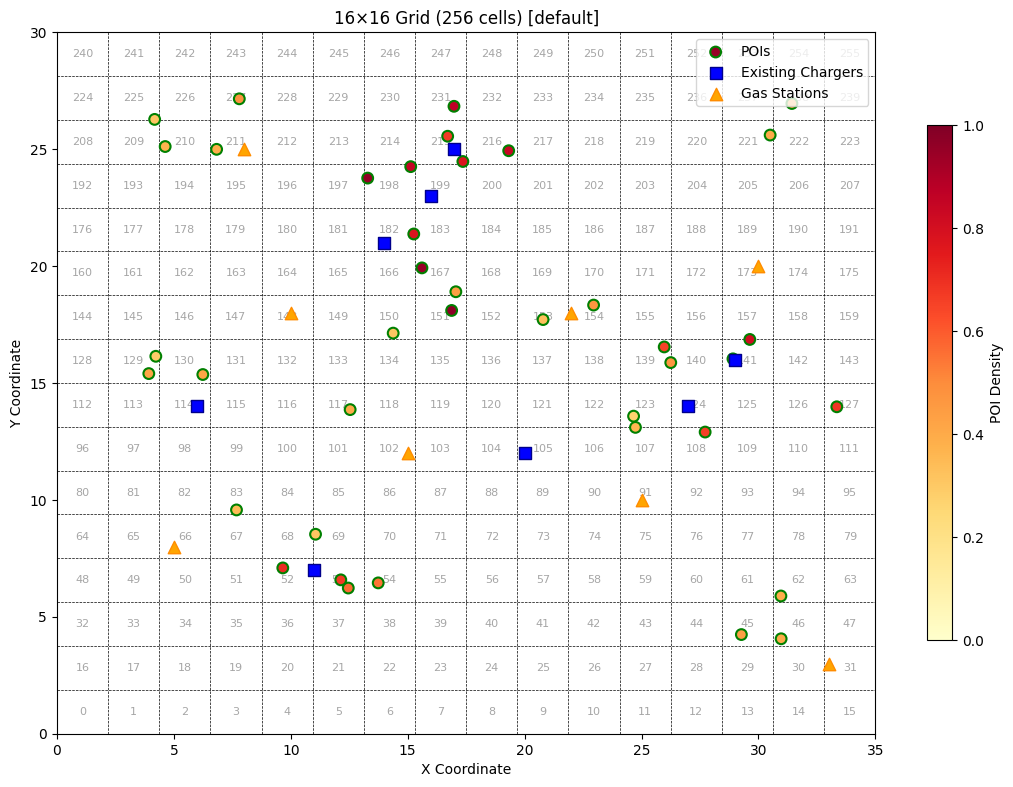

  Grid Info:
    Grid   31 (row=1, col=15): 1 gas station(s)
    Grid   45 (row=2, col=13): 1 POI(s) [densities: 0.44]
    Grid   46 (row=2, col=14): 1 POI(s) [densities: 0.40]
    Grid   52 (row=3, col=4): 1 POI(s) [densities: 0.71]
    Grid   53 (row=3, col=5): 2 POI(s) [densities: 0.57, 0.67] | 1 charger(s)
    Grid   54 (row=3, col=6): 1 POI(s) [densities: 0.55]
    Grid   62 (row=3, col=14): 1 POI(s) [densities: 0.39]
    Grid   66 (row=4, col=2): 1 gas station(s)
    Grid   69 (row=4, col=5): 1 POI(s) [densities: 0.31]
    Grid   83 (row=5, col=3): 1 POI(s) [densities: 0.34]
    Grid   91 (row=5, col=11): 1 gas station(s)
    Grid  102 (row=6, col=6): 1 gas station(s)
    Grid  105 (row=6, col=9): 1 charger(s)
    Grid  107 (row=6, col=11): 1 POI(s) [densities: 0.36]
    Grid  108 (row=6, col=12): 1 POI(s) [densities: 0.66]
    Grid  114 (row=7, col=2): 1 charger(s)
    Grid  117 (row=7, col=5): 1 POI(s) [densities: 0.40]
    Grid  123 (row=7, col=11): 1 POI(s) [densities: 0.27]


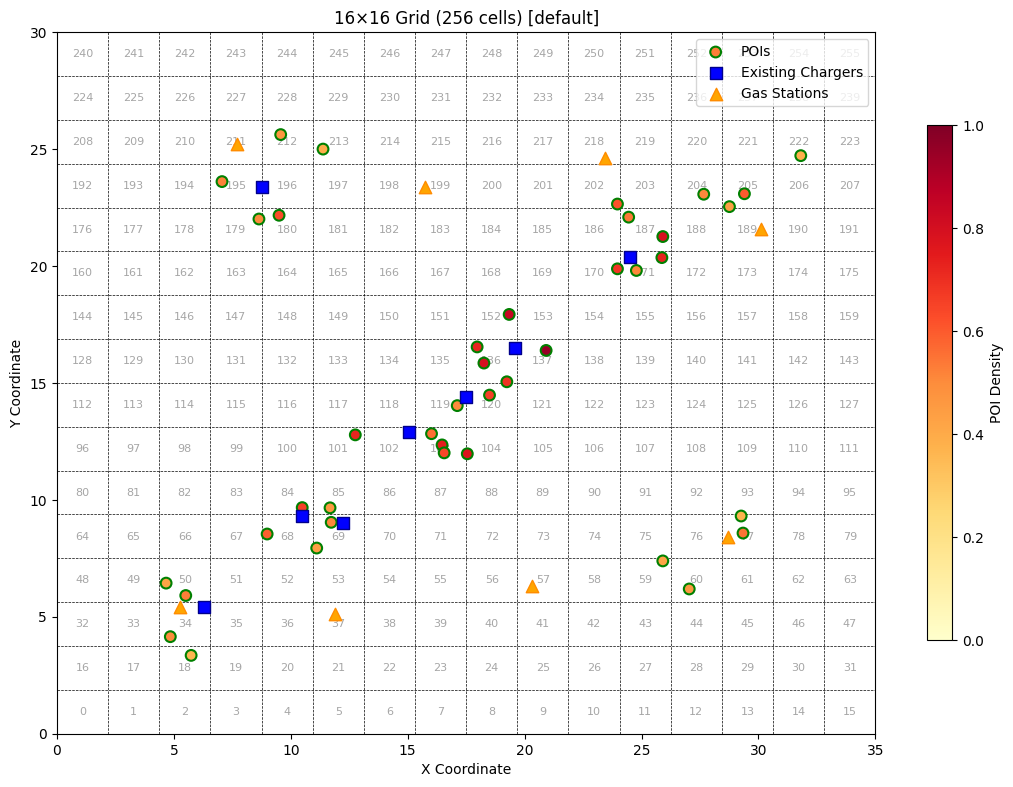

  Grid Info:
    Grid   18 (row=1, col=2): 1 POI(s) [densities: 0.36]
    Grid   34 (row=2, col=2): 1 POI(s) [densities: 0.50] | 1 charger(s) | 1 gas station(s)
    Grid   37 (row=2, col=5): 1 gas station(s)
    Grid   50 (row=3, col=2): 2 POI(s) [densities: 0.53, 0.42]
    Grid   57 (row=3, col=9): 1 gas station(s)
    Grid   59 (row=3, col=11): 1 POI(s) [densities: 0.42]
    Grid   60 (row=3, col=12): 1 POI(s) [densities: 0.46]
    Grid   68 (row=4, col=4): 1 POI(s) [densities: 0.59] | 1 charger(s)
    Grid   69 (row=4, col=5): 2 POI(s) [densities: 0.51, 0.44] | 1 charger(s)
    Grid   77 (row=4, col=13): 2 POI(s) [densities: 0.55, 0.37] | 1 gas station(s)
    Grid   84 (row=5, col=4): 1 POI(s) [densities: 0.66]
    Grid   85 (row=5, col=5): 1 POI(s) [densities: 0.46]
    Grid  101 (row=6, col=5): 1 POI(s) [densities: 0.72]
    Grid  102 (row=6, col=6): 1 charger(s)
    Grid  103 (row=6, col=7): 3 POI(s) [densities: 0.74, 0.64, 0.56]
    Grid  104 (row=6, col=8): 1 POI(s) [densities:

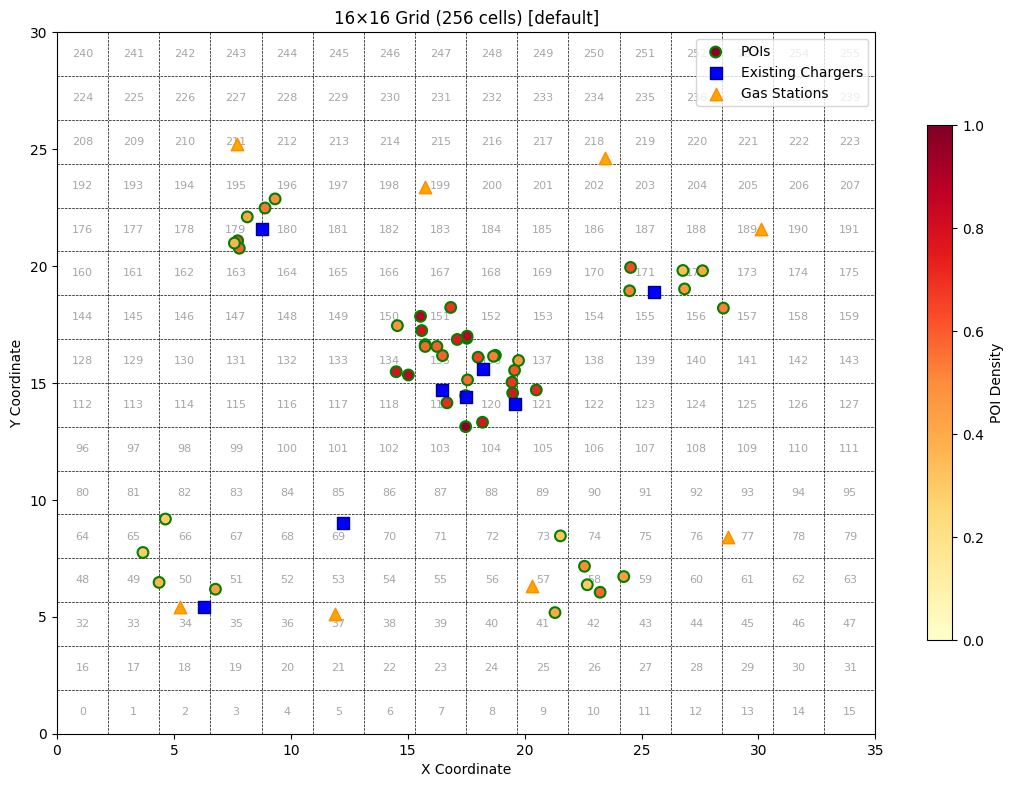

  Grid Info:
    Grid   34 (row=2, col=2): 1 charger(s) | 1 gas station(s)
    Grid   37 (row=2, col=5): 1 gas station(s)
    Grid   41 (row=2, col=9): 1 POI(s) [densities: 0.41]
    Grid   49 (row=3, col=1): 1 POI(s) [densities: 0.36]
    Grid   51 (row=3, col=3): 1 POI(s) [densities: 0.44]
    Grid   57 (row=3, col=9): 1 gas station(s)
    Grid   58 (row=3, col=10): 3 POI(s) [densities: 0.58, 0.50, 0.30]
    Grid   59 (row=3, col=11): 1 POI(s) [densities: 0.45]
    Grid   65 (row=4, col=1): 1 POI(s) [densities: 0.29]
    Grid   66 (row=4, col=2): 1 POI(s) [densities: 0.29]
    Grid   69 (row=4, col=5): 1 charger(s)
    Grid   73 (row=4, col=9): 1 POI(s) [densities: 0.32]
    Grid   77 (row=4, col=13): 1 gas station(s)
    Grid  119 (row=7, col=7): 3 POI(s) [densities: 0.97, 0.71, 0.83] | 1 charger(s)
    Grid  120 (row=7, col=8): 2 POI(s) [densities: 0.78, 0.78] | 2 charger(s)
    Grid  121 (row=7, col=9): 1 POI(s) [densities: 0.72]
    Grid  134 (row=8, col=6): 2 POI(s) [densities: 

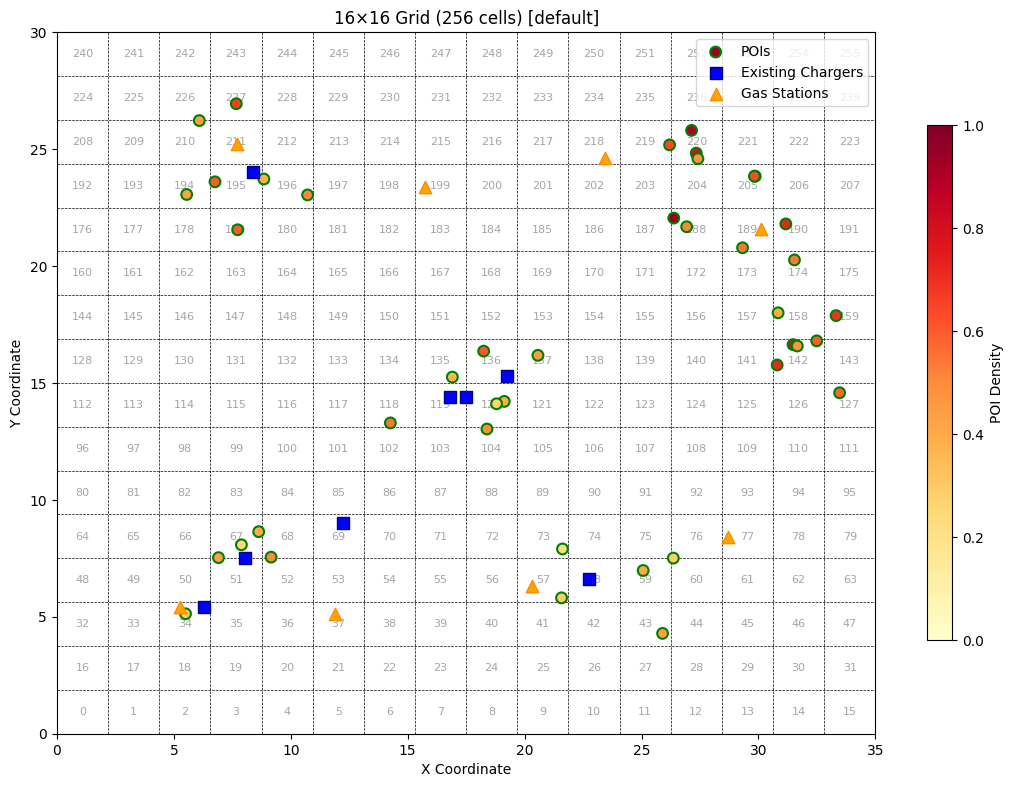

  Grid Info:
    Grid   34 (row=2, col=2): 1 POI(s) [densities: 0.30] | 1 charger(s) | 1 gas station(s)
    Grid   37 (row=2, col=5): 1 gas station(s)
    Grid   43 (row=2, col=11): 1 POI(s) [densities: 0.43]
    Grid   57 (row=3, col=9): 1 POI(s) [densities: 0.29] | 1 gas station(s)
    Grid   58 (row=3, col=10): 1 charger(s)
    Grid   59 (row=3, col=11): 1 POI(s) [densities: 0.40]
    Grid   67 (row=4, col=3): 3 POI(s) [densities: 0.43, 0.40, 0.25] | 1 charger(s)
    Grid   68 (row=4, col=4): 1 POI(s) [densities: 0.51]
    Grid   69 (row=4, col=5): 1 charger(s)
    Grid   73 (row=4, col=9): 1 POI(s) [densities: 0.22]
    Grid   76 (row=4, col=12): 1 POI(s) [densities: 0.29]
    Grid   77 (row=4, col=13): 1 gas station(s)
    Grid  104 (row=6, col=8): 1 POI(s) [densities: 0.49]
    Grid  118 (row=7, col=6): 1 POI(s) [densities: 0.55]
    Grid  119 (row=7, col=7): 1 charger(s)
    Grid  120 (row=7, col=8): 2 POI(s) [densities: 0.39, 0.27] | 1 charger(s)
    Grid  127 (row=7, col=15): 

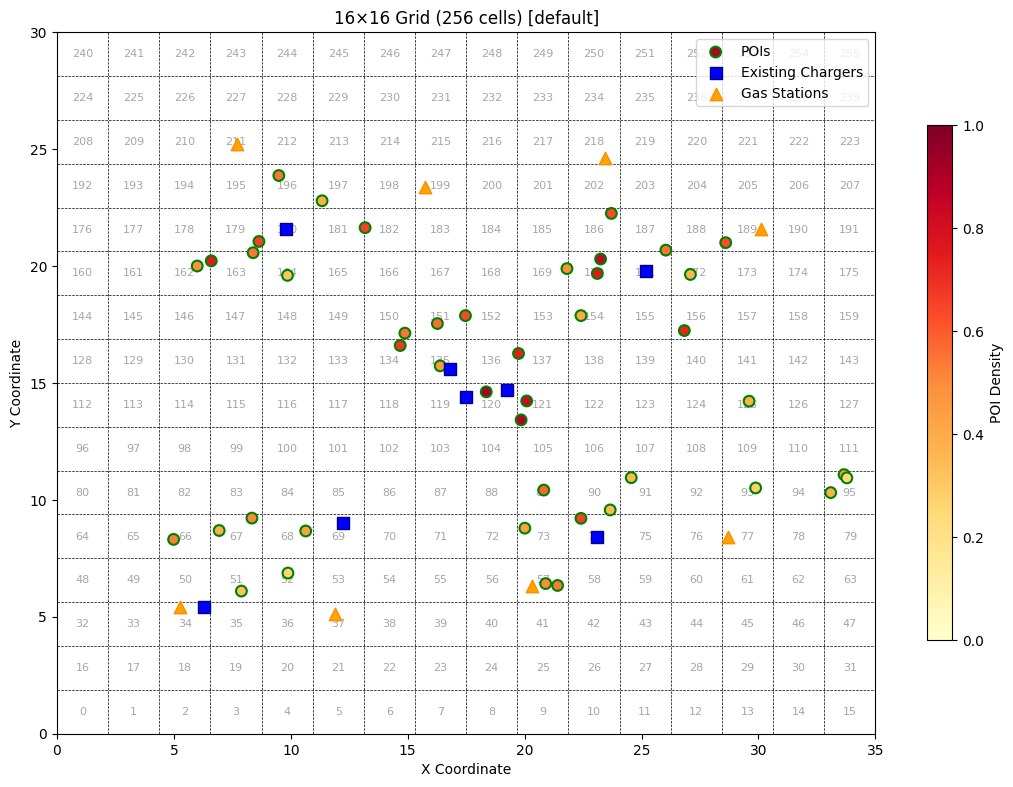

  Grid Info:
    Grid   34 (row=2, col=2): 1 charger(s) | 1 gas station(s)
    Grid   37 (row=2, col=5): 1 gas station(s)
    Grid   51 (row=3, col=3): 1 POI(s) [densities: 0.33]
    Grid   52 (row=3, col=4): 1 POI(s) [densities: 0.26]
    Grid   57 (row=3, col=9): 2 POI(s) [densities: 0.54, 0.50] | 1 gas station(s)
    Grid   66 (row=4, col=2): 1 POI(s) [densities: 0.53]
    Grid   67 (row=4, col=3): 2 POI(s) [densities: 0.51, 0.39]
    Grid   68 (row=4, col=4): 1 POI(s) [densities: 0.43]
    Grid   69 (row=4, col=5): 1 charger(s)
    Grid   73 (row=4, col=9): 1 POI(s) [densities: 0.44]
    Grid   74 (row=4, col=10): 1 POI(s) [densities: 0.66] | 1 charger(s)
    Grid   77 (row=4, col=13): 1 gas station(s)
    Grid   89 (row=5, col=9): 1 POI(s) [densities: 0.58]
    Grid   90 (row=5, col=10): 1 POI(s) [densities: 0.35]
    Grid   91 (row=5, col=11): 1 POI(s) [densities: 0.35]
    Grid   93 (row=5, col=13): 1 POI(s) [densities: 0.28]
    Grid   95 (row=5, col=15): 3 POI(s) [densities: 0

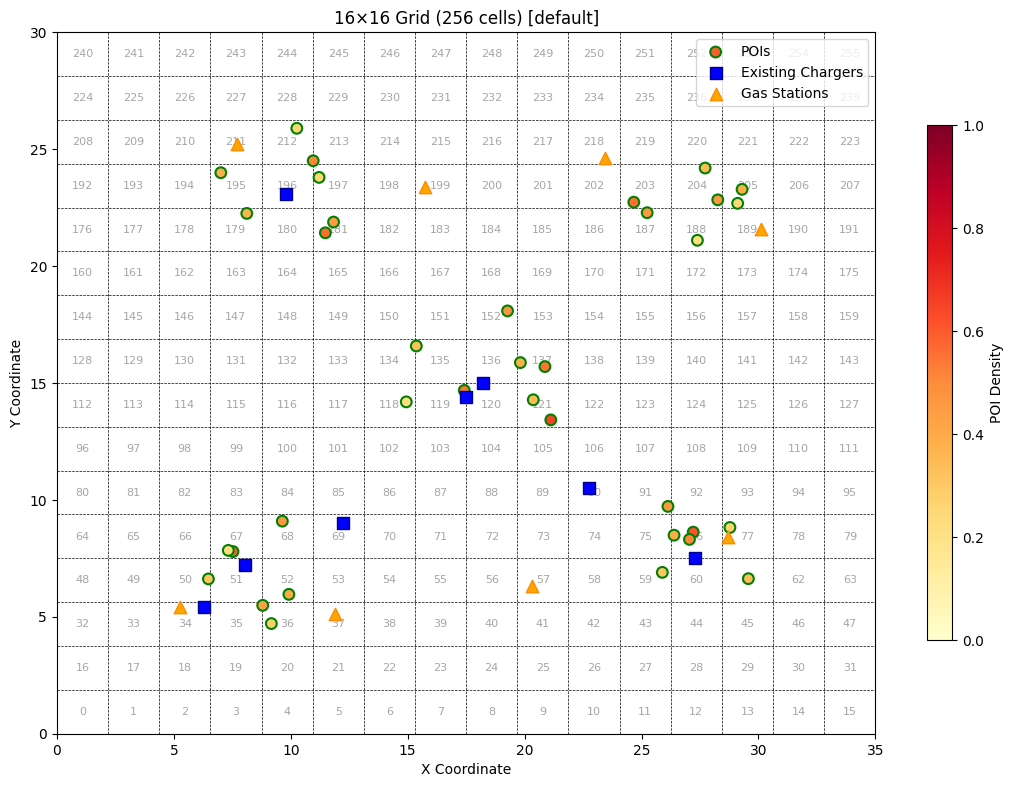

  Grid Info:
    Grid   34 (row=2, col=2): 1 charger(s) | 1 gas station(s)
    Grid   36 (row=2, col=4): 2 POI(s) [densities: 0.43, 0.28]
    Grid   37 (row=2, col=5): 1 gas station(s)
    Grid   50 (row=3, col=2): 1 POI(s) [densities: 0.31]
    Grid   51 (row=3, col=3): 1 charger(s)
    Grid   52 (row=3, col=4): 1 POI(s) [densities: 0.41]
    Grid   57 (row=3, col=9): 1 gas station(s)
    Grid   59 (row=3, col=11): 1 POI(s) [densities: 0.31]
    Grid   61 (row=3, col=13): 1 POI(s) [densities: 0.34]
    Grid   67 (row=4, col=3): 2 POI(s) [densities: 0.59, 0.23]
    Grid   68 (row=4, col=4): 1 POI(s) [densities: 0.47]
    Grid   69 (row=4, col=5): 1 charger(s)
    Grid   76 (row=4, col=12): 3 POI(s) [densities: 0.62, 0.51, 0.40] | 1 charger(s)
    Grid   77 (row=4, col=13): 1 POI(s) [densities: 0.27] | 1 gas station(s)
    Grid   90 (row=5, col=10): 1 charger(s)
    Grid   91 (row=5, col=11): 1 POI(s) [densities: 0.47]
    Grid  118 (row=7, col=6): 1 POI(s) [densities: 0.22]
    Grid  1

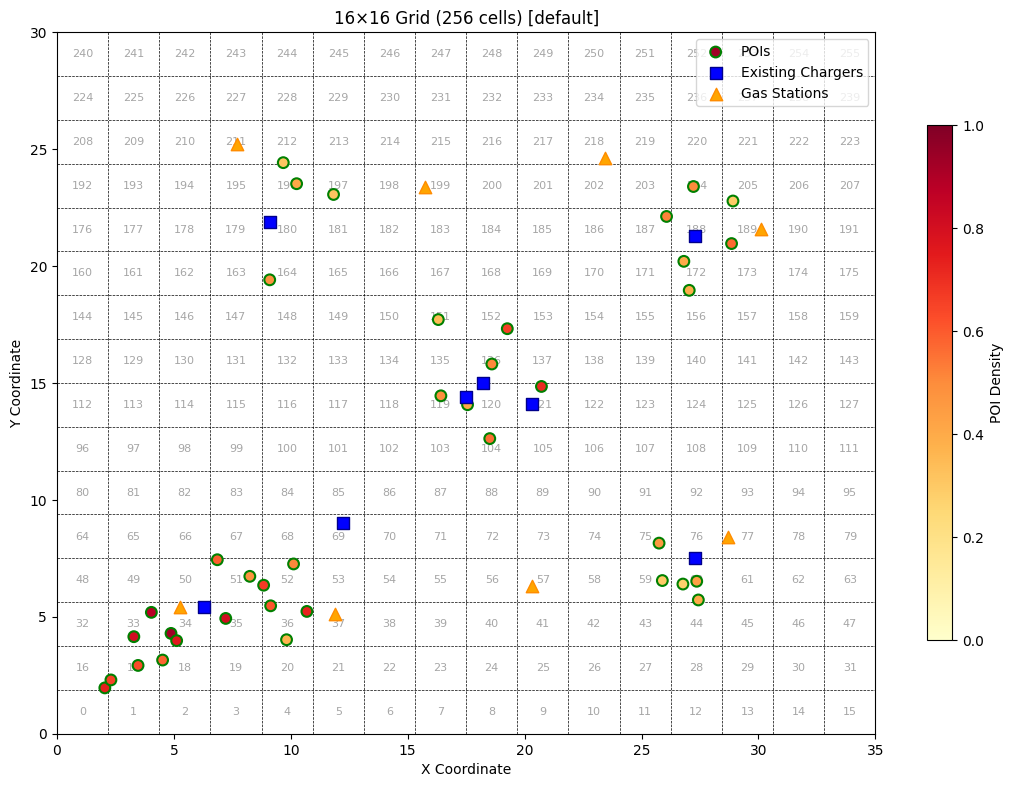

  Grid Info:
    Grid   16 (row=1, col=0): 1 POI(s) [densities: 0.74]
    Grid   17 (row=1, col=1): 2 POI(s) [densities: 0.65, 0.63]
    Grid   18 (row=1, col=2): 1 POI(s) [densities: 0.58]
    Grid   33 (row=2, col=1): 2 POI(s) [densities: 0.88, 0.81]
    Grid   34 (row=2, col=2): 2 POI(s) [densities: 0.93, 0.76] | 1 charger(s) | 1 gas station(s)
    Grid   35 (row=2, col=3): 1 POI(s) [densities: 0.81]
    Grid   36 (row=2, col=4): 3 POI(s) [densities: 0.73, 0.61, 0.37]
    Grid   37 (row=2, col=5): 1 gas station(s)
    Grid   51 (row=3, col=3): 2 POI(s) [densities: 0.59, 0.48]
    Grid   52 (row=3, col=4): 2 POI(s) [densities: 0.67, 0.51]
    Grid   57 (row=3, col=9): 1 gas station(s)
    Grid   59 (row=3, col=11): 1 POI(s) [densities: 0.30]
    Grid   60 (row=3, col=12): 3 POI(s) [densities: 0.43, 0.40, 0.28]
    Grid   69 (row=4, col=5): 1 charger(s)
    Grid   75 (row=4, col=11): 1 POI(s) [densities: 0.46]
    Grid   76 (row=4, col=12): 1 charger(s)
    Grid   77 (row=4, col=13): 

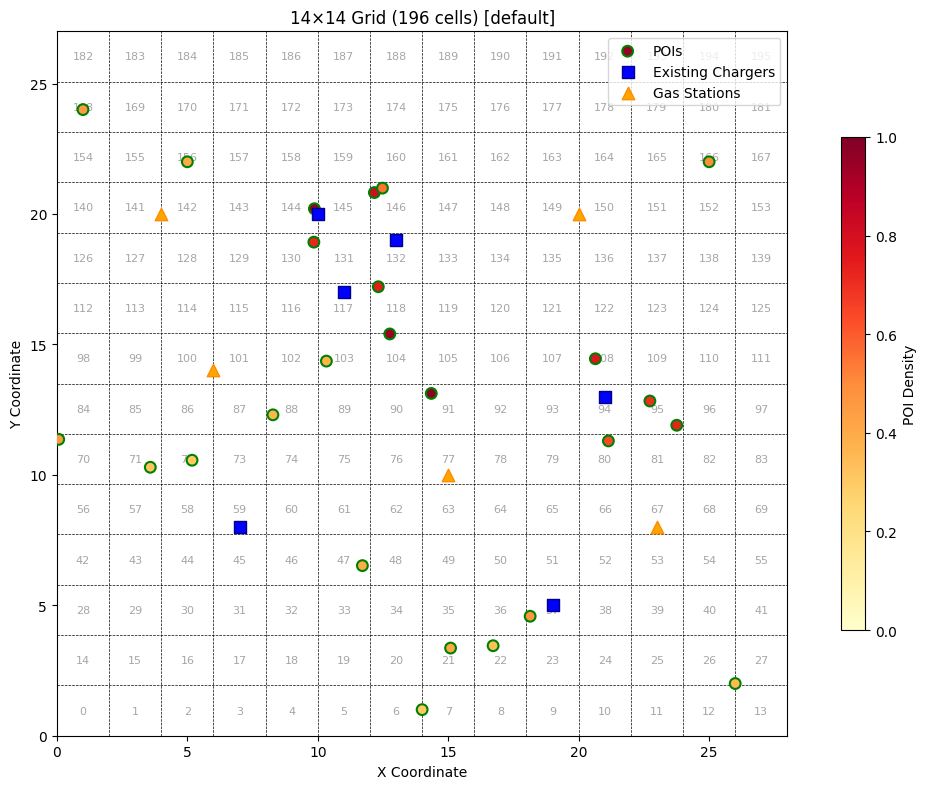

  Grid Info:
    Grid    7 (row=0, col=7): 1 POI(s) [densities: 0.30]
    Grid   21 (row=1, col=7): 1 POI(s) [densities: 0.41]
    Grid   22 (row=1, col=8): 1 POI(s) [densities: 0.33]
    Grid   27 (row=1, col=13): 1 POI(s) [densities: 0.35]
    Grid   37 (row=2, col=9): 1 POI(s) [densities: 0.47] | 1 charger(s)
    Grid   47 (row=3, col=5): 1 POI(s) [densities: 0.40]
    Grid   59 (row=4, col=3): 1 charger(s)
    Grid   67 (row=4, col=11): 1 gas station(s)
    Grid   70 (row=5, col=0): 1 POI(s) [densities: 0.46]
    Grid   71 (row=5, col=1): 1 POI(s) [densities: 0.32]
    Grid   72 (row=5, col=2): 1 POI(s) [densities: 0.30]
    Grid   77 (row=5, col=7): 1 gas station(s)
    Grid   80 (row=5, col=10): 1 POI(s) [densities: 0.64]
    Grid   88 (row=6, col=4): 1 POI(s) [densities: 0.36]
    Grid   91 (row=6, col=7): 1 POI(s) [densities: 0.97]
    Grid   94 (row=6, col=10): 1 charger(s)
    Grid   95 (row=6, col=11): 2 POI(s) [densities: 0.73, 0.70]
    Grid  101 (row=7, col=3): 1 gas stat

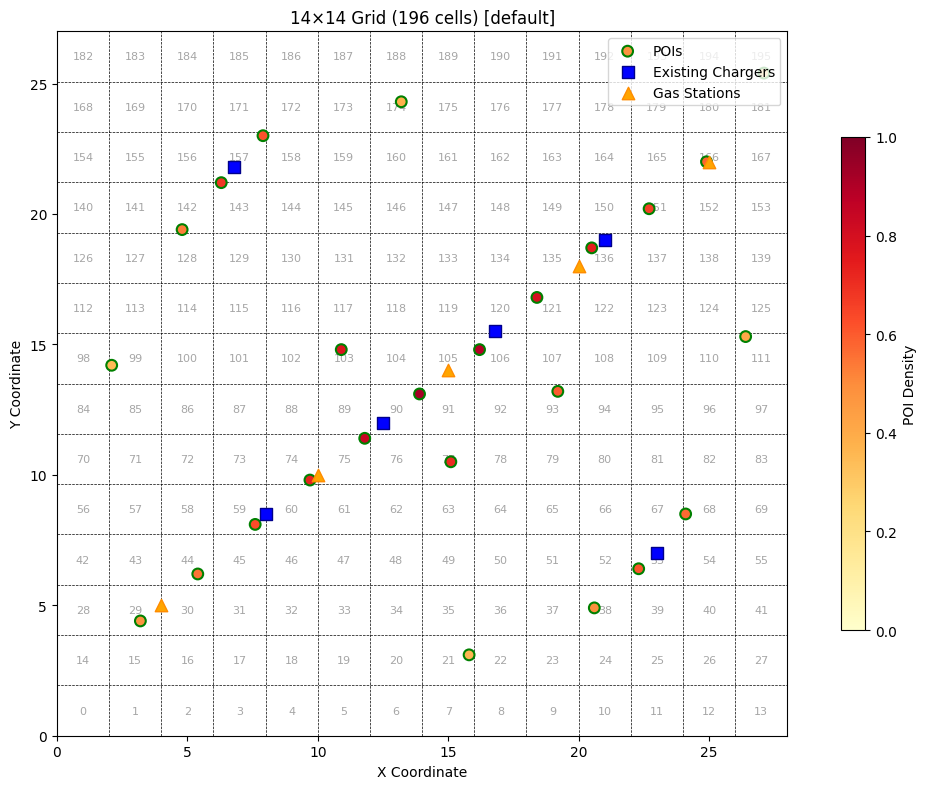

  Grid Info:
    Grid   21 (row=1, col=7): 1 POI(s) [densities: 0.36]
    Grid   29 (row=2, col=1): 1 POI(s) [densities: 0.48]
    Grid   30 (row=2, col=2): 1 gas station(s)
    Grid   38 (row=2, col=10): 1 POI(s) [densities: 0.49]
    Grid   44 (row=3, col=2): 1 POI(s) [densities: 0.55]
    Grid   53 (row=3, col=11): 1 POI(s) [densities: 0.61] | 1 charger(s)
    Grid   59 (row=4, col=3): 1 POI(s) [densities: 0.63]
    Grid   60 (row=4, col=4): 1 charger(s)
    Grid   68 (row=4, col=12): 1 POI(s) [densities: 0.57]
    Grid   74 (row=5, col=4): 1 POI(s) [densities: 0.73]
    Grid   75 (row=5, col=5): 1 POI(s) [densities: 0.84] | 1 gas station(s)
    Grid   77 (row=5, col=7): 1 POI(s) [densities: 0.71]
    Grid   90 (row=6, col=6): 1 POI(s) [densities: 0.92] | 1 charger(s)
    Grid   93 (row=6, col=9): 1 POI(s) [densities: 0.60]
    Grid   99 (row=7, col=1): 1 POI(s) [densities: 0.35]
    Grid  103 (row=7, col=5): 1 POI(s) [densities: 0.77]
    Grid  105 (row=7, col=7): 1 gas station(s)


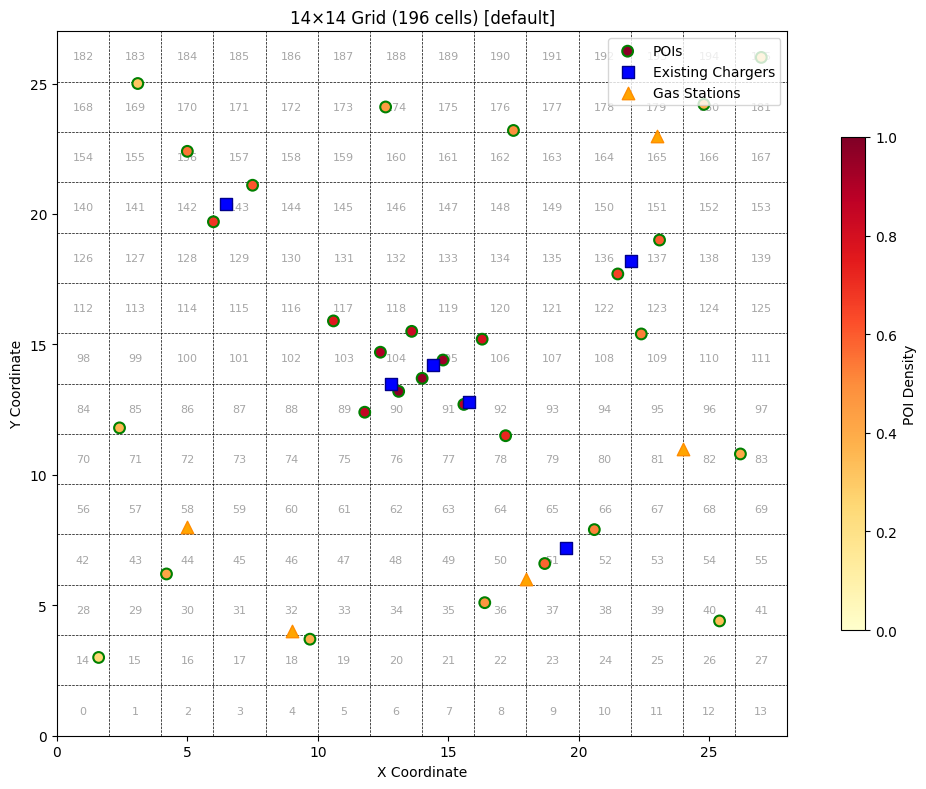

  Grid Info:
    Grid   14 (row=1, col=0): 1 POI(s) [densities: 0.25]
    Grid   18 (row=1, col=4): 1 POI(s) [densities: 0.39]
    Grid   32 (row=2, col=4): 1 gas station(s)
    Grid   36 (row=2, col=8): 1 POI(s) [densities: 0.47]
    Grid   40 (row=2, col=12): 1 POI(s) [densities: 0.34]
    Grid   44 (row=3, col=2): 1 POI(s) [densities: 0.42]
    Grid   51 (row=3, col=9): 1 POI(s) [densities: 0.58] | 1 charger(s) | 1 gas station(s)
    Grid   58 (row=4, col=2): 1 gas station(s)
    Grid   66 (row=4, col=10): 1 POI(s) [densities: 0.52]
    Grid   78 (row=5, col=8): 1 POI(s) [densities: 0.72]
    Grid   82 (row=5, col=12): 1 gas station(s)
    Grid   83 (row=5, col=13): 1 POI(s) [densities: 0.41]
    Grid   85 (row=6, col=1): 1 POI(s) [densities: 0.36]
    Grid   89 (row=6, col=5): 1 POI(s) [densities: 0.85]
    Grid   90 (row=6, col=6): 1 POI(s) [densities: 0.98]
    Grid   91 (row=6, col=7): 1 POI(s) [densities: 0.88] | 1 charger(s)
    Grid  104 (row=7, col=6): 1 POI(s) [densities: 0

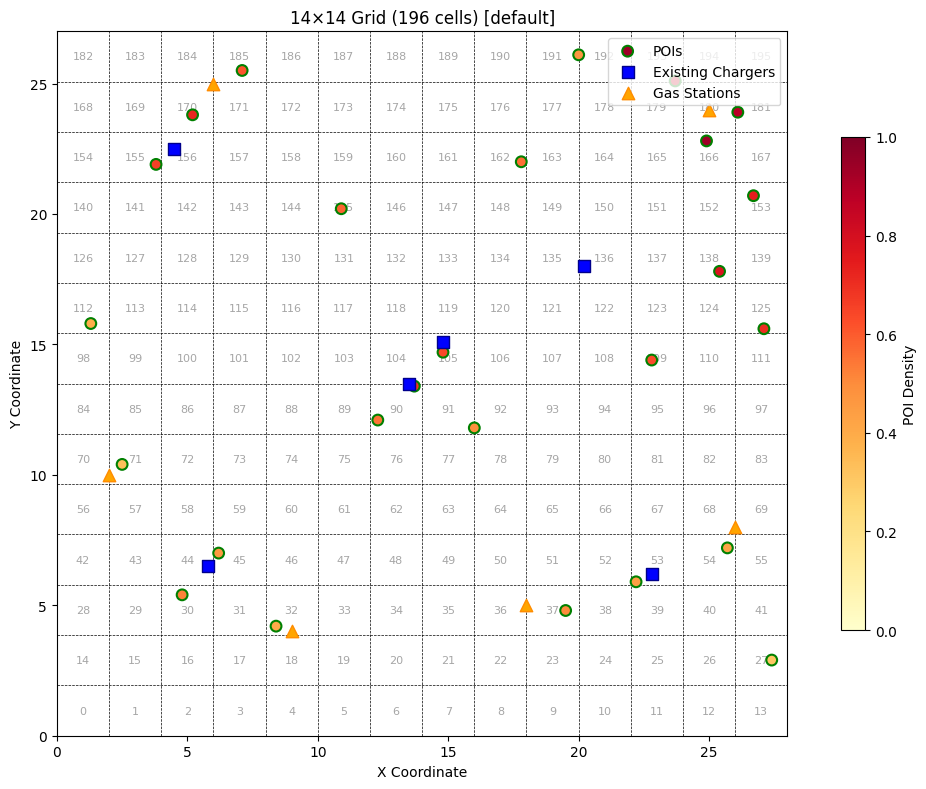

  Grid Info:
    Grid   27 (row=1, col=13): 1 POI(s) [densities: 0.31]
    Grid   30 (row=2, col=2): 1 POI(s) [densities: 0.52]
    Grid   32 (row=2, col=4): 1 POI(s) [densities: 0.40] | 1 gas station(s)
    Grid   37 (row=2, col=9): 1 POI(s) [densities: 0.50] | 1 gas station(s)
    Grid   44 (row=3, col=2): 1 charger(s)
    Grid   45 (row=3, col=3): 1 POI(s) [densities: 0.46]
    Grid   53 (row=3, col=11): 1 POI(s) [densities: 0.44] | 1 charger(s)
    Grid   54 (row=3, col=12): 1 POI(s) [densities: 0.42]
    Grid   69 (row=4, col=13): 1 gas station(s)
    Grid   71 (row=5, col=1): 1 POI(s) [densities: 0.33] | 1 gas station(s)
    Grid   90 (row=6, col=6): 2 POI(s) [densities: 0.69, 0.55]
    Grid   92 (row=6, col=8): 1 POI(s) [densities: 0.49]
    Grid  104 (row=7, col=6): 1 charger(s)
    Grid  105 (row=7, col=7): 1 POI(s) [densities: 0.64] | 1 charger(s)
    Grid  109 (row=7, col=11): 1 POI(s) [densities: 0.63]
    Grid  112 (row=8, col=0): 1 POI(s) [densities: 0.39]
    Grid  125 (

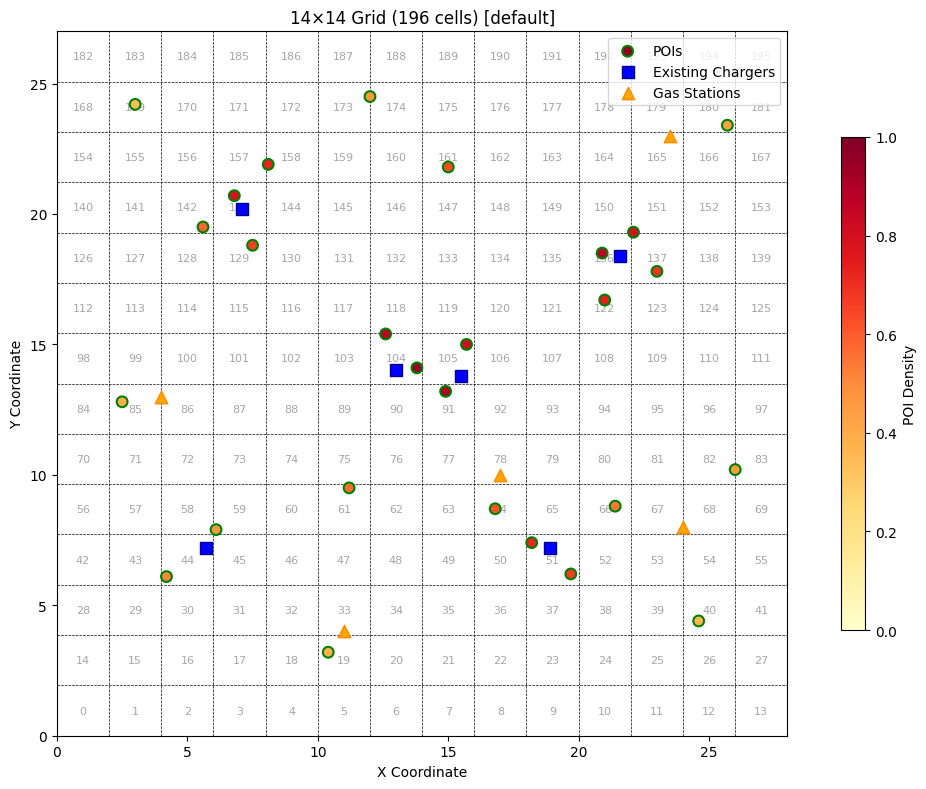

  Grid Info:
    Grid   19 (row=1, col=5): 1 POI(s) [densities: 0.38]
    Grid   33 (row=2, col=5): 1 gas station(s)
    Grid   40 (row=2, col=12): 1 POI(s) [densities: 0.36]
    Grid   44 (row=3, col=2): 1 POI(s) [densities: 0.51] | 1 charger(s)
    Grid   51 (row=3, col=9): 2 POI(s) [densities: 0.72, 0.67] | 1 charger(s)
    Grid   59 (row=4, col=3): 1 POI(s) [densities: 0.47]
    Grid   61 (row=4, col=5): 1 POI(s) [densities: 0.57]
    Grid   64 (row=4, col=8): 1 POI(s) [densities: 0.61]
    Grid   66 (row=4, col=10): 1 POI(s) [densities: 0.54]
    Grid   68 (row=4, col=12): 1 gas station(s)
    Grid   78 (row=5, col=8): 1 gas station(s)
    Grid   83 (row=5, col=13): 1 POI(s) [densities: 0.45]
    Grid   85 (row=6, col=1): 1 POI(s) [densities: 0.40]
    Grid   86 (row=6, col=2): 1 gas station(s)
    Grid   91 (row=6, col=7): 1 POI(s) [densities: 0.91]
    Grid  104 (row=7, col=6): 2 POI(s) [densities: 0.96, 0.88] | 1 charger(s)
    Grid  105 (row=7, col=7): 1 POI(s) [densities: 0.8

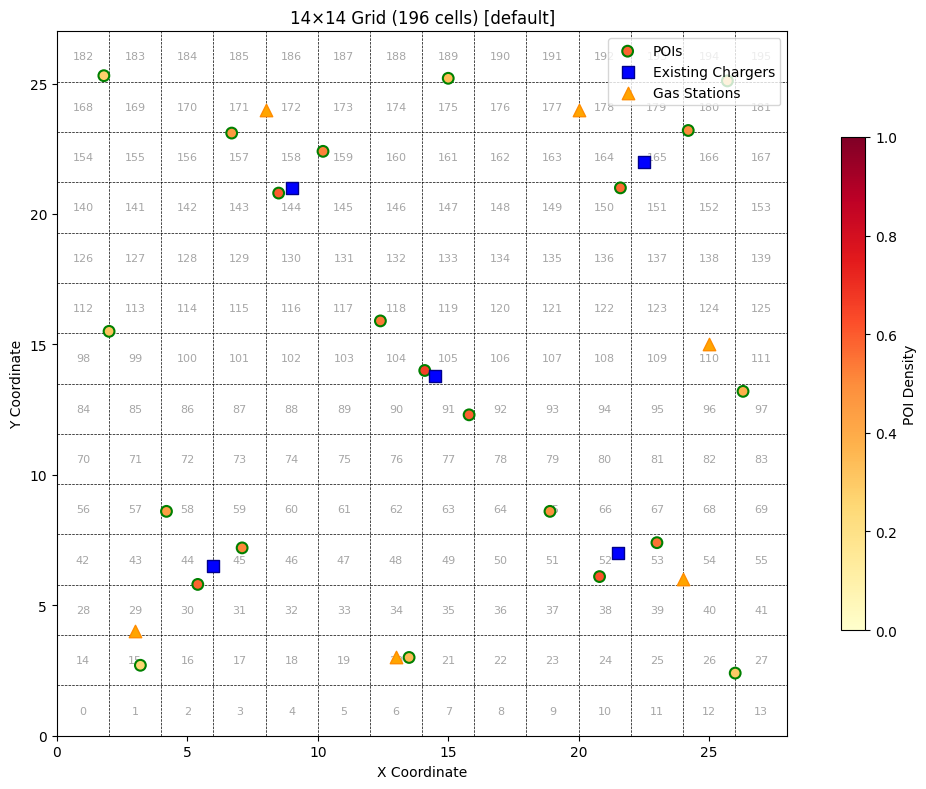

  Grid Info:
    Grid   15 (row=1, col=1): 1 POI(s) [densities: 0.26]
    Grid   20 (row=1, col=6): 1 POI(s) [densities: 0.35] | 1 gas station(s)
    Grid   27 (row=1, col=13): 1 POI(s) [densities: 0.30]
    Grid   29 (row=2, col=1): 1 gas station(s)
    Grid   44 (row=3, col=2): 1 POI(s) [densities: 0.58]
    Grid   45 (row=3, col=3): 1 POI(s) [densities: 0.51] | 1 charger(s)
    Grid   52 (row=3, col=10): 1 POI(s) [densities: 0.62] | 1 charger(s)
    Grid   53 (row=3, col=11): 1 POI(s) [densities: 0.55]
    Grid   54 (row=3, col=12): 1 gas station(s)
    Grid   58 (row=4, col=2): 1 POI(s) [densities: 0.44]
    Grid   65 (row=4, col=9): 1 POI(s) [densities: 0.49]
    Grid   91 (row=6, col=7): 1 POI(s) [densities: 0.59]
    Grid   97 (row=6, col=13): 1 POI(s) [densities: 0.38]
    Grid  105 (row=7, col=7): 1 POI(s) [densities: 0.66] | 1 charger(s)
    Grid  110 (row=7, col=12): 1 gas station(s)
    Grid  113 (row=8, col=1): 1 POI(s) [densities: 0.32]
    Grid  118 (row=8, col=6): 1 POI

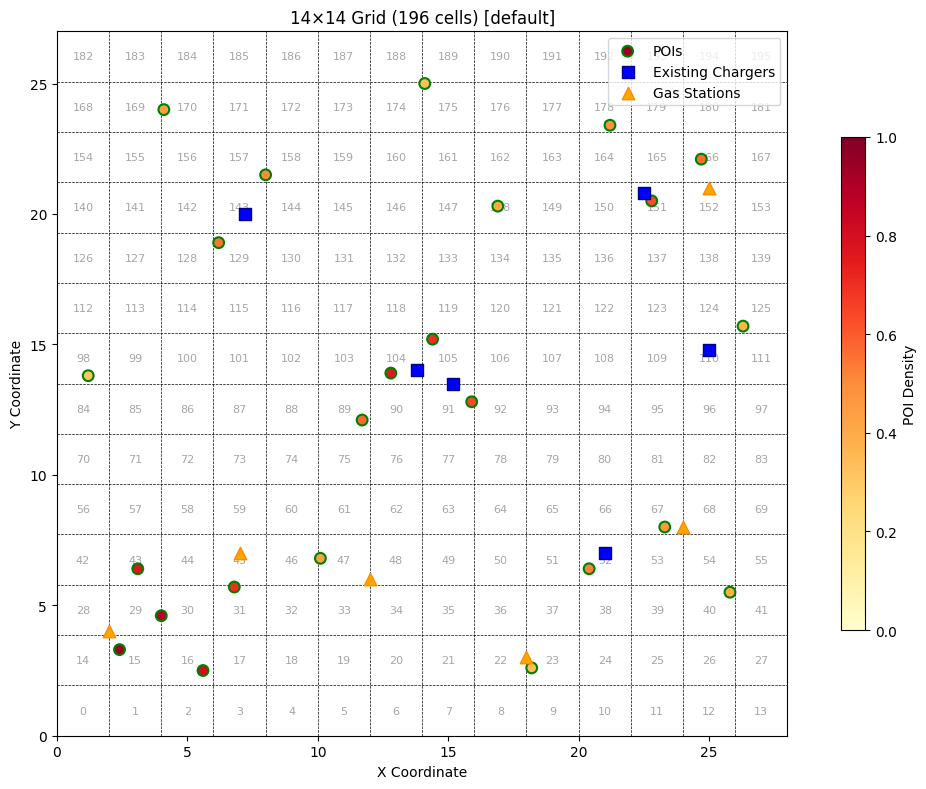

  Grid Info:
    Grid   15 (row=1, col=1): 1 POI(s) [densities: 0.93]
    Grid   16 (row=1, col=2): 1 POI(s) [densities: 0.81]
    Grid   23 (row=1, col=9): 1 POI(s) [densities: 0.34] | 1 gas station(s)
    Grid   29 (row=2, col=1): 1 gas station(s)
    Grid   30 (row=2, col=2): 1 POI(s) [densities: 0.88]
    Grid   31 (row=2, col=3): 1 POI(s) [densities: 0.70]
    Grid   40 (row=2, col=12): 1 POI(s) [densities: 0.39]
    Grid   43 (row=3, col=1): 1 POI(s) [densities: 0.77]
    Grid   45 (row=3, col=3): 1 gas station(s)
    Grid   47 (row=3, col=5): 1 POI(s) [densities: 0.44]
    Grid   48 (row=3, col=6): 1 gas station(s)
    Grid   52 (row=3, col=10): 1 POI(s) [densities: 0.52] | 1 charger(s)
    Grid   67 (row=4, col=11): 1 POI(s) [densities: 0.46]
    Grid   68 (row=4, col=12): 1 gas station(s)
    Grid   89 (row=6, col=5): 1 POI(s) [densities: 0.57]
    Grid   91 (row=6, col=7): 1 POI(s) [densities: 0.64]
    Grid   98 (row=7, col=0): 1 POI(s) [densities: 0.31]
    Grid  104 (row=7

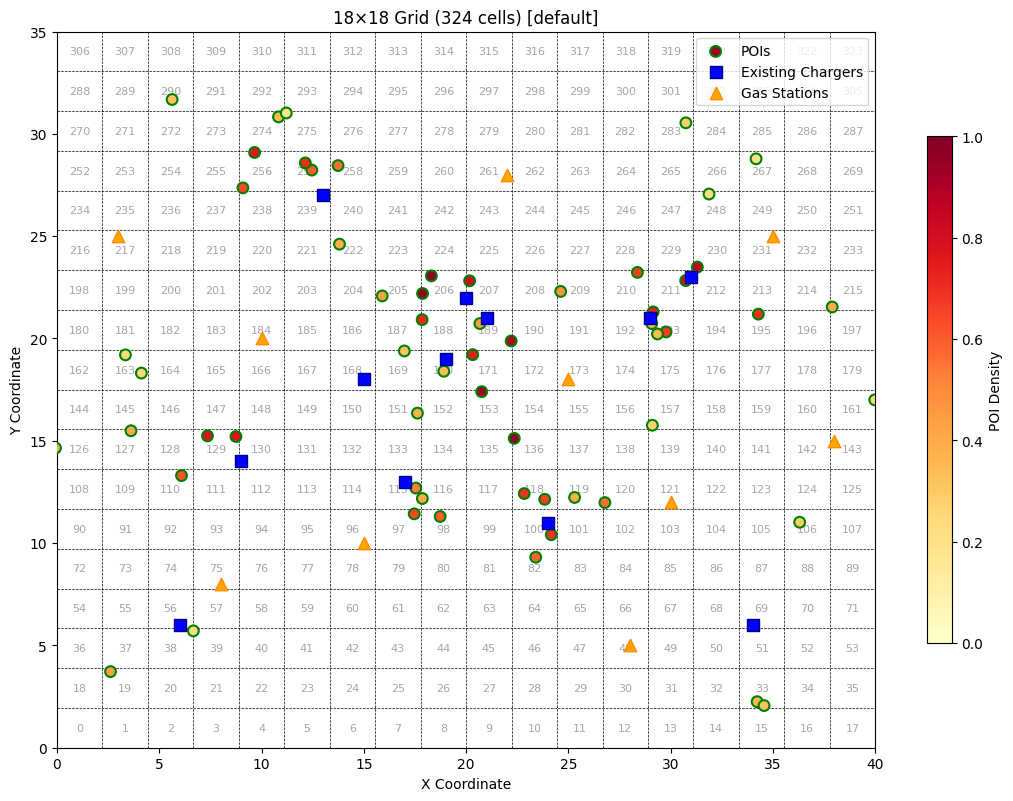

  Grid Info:
    Grid   19 (row=1, col=1): 1 POI(s) [densities: 0.43]
    Grid   33 (row=1, col=15): 2 POI(s) [densities: 0.35, 0.32]
    Grid   39 (row=2, col=3): 1 POI(s) [densities: 0.23]
    Grid   48 (row=2, col=12): 1 gas station(s)
    Grid   56 (row=3, col=2): 1 charger(s)
    Grid   69 (row=3, col=15): 1 charger(s)
    Grid   75 (row=4, col=3): 1 gas station(s)
    Grid   82 (row=4, col=10): 1 POI(s) [densities: 0.58]
    Grid   96 (row=5, col=6): 1 gas station(s)
    Grid   97 (row=5, col=7): 1 POI(s) [densities: 0.64]
    Grid   98 (row=5, col=8): 1 POI(s) [densities: 0.60]
    Grid  100 (row=5, col=10): 1 POI(s) [densities: 0.69] | 1 charger(s)
    Grid  106 (row=5, col=16): 1 POI(s) [densities: 0.28]
    Grid  110 (row=6, col=2): 1 POI(s) [densities: 0.61]
    Grid  115 (row=6, col=7): 1 POI(s) [densities: 0.53] | 1 charger(s)
    Grid  116 (row=6, col=8): 1 POI(s) [densities: 0.40]
    Grid  118 (row=6, col=10): 2 POI(s) [densities: 0.69, 0.65]
    Grid  119 (row=6, col=1

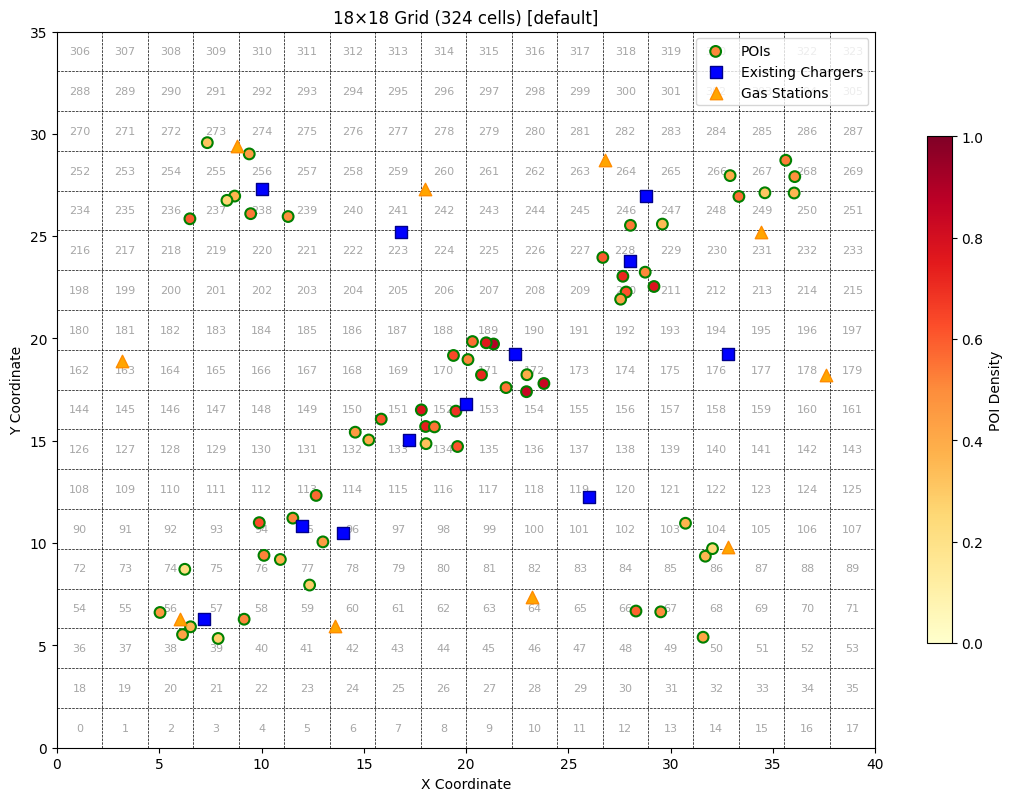

  Grid Info:
    Grid   38 (row=2, col=2): 1 POI(s) [densities: 0.43]
    Grid   39 (row=2, col=3): 1 POI(s) [densities: 0.28]
    Grid   50 (row=2, col=14): 1 POI(s) [densities: 0.42]
    Grid   56 (row=3, col=2): 2 POI(s) [densities: 0.46, 0.36] | 1 gas station(s)
    Grid   57 (row=3, col=3): 1 charger(s)
    Grid   58 (row=3, col=4): 1 POI(s) [densities: 0.51]
    Grid   60 (row=3, col=6): 1 gas station(s)
    Grid   64 (row=3, col=10): 1 gas station(s)
    Grid   66 (row=3, col=12): 1 POI(s) [densities: 0.58]
    Grid   67 (row=3, col=13): 1 POI(s) [densities: 0.50]
    Grid   74 (row=4, col=2): 1 POI(s) [densities: 0.22]
    Grid   76 (row=4, col=4): 2 POI(s) [densities: 0.52, 0.39]
    Grid   77 (row=4, col=5): 1 POI(s) [densities: 0.29]
    Grid   86 (row=4, col=14): 1 POI(s) [densities: 0.36]
    Grid   94 (row=5, col=4): 1 POI(s) [densities: 0.63]
    Grid   95 (row=5, col=5): 2 POI(s) [densities: 0.51, 0.45] | 1 charger(s)
    Grid   96 (row=5, col=6): 1 charger(s)
    Grid 

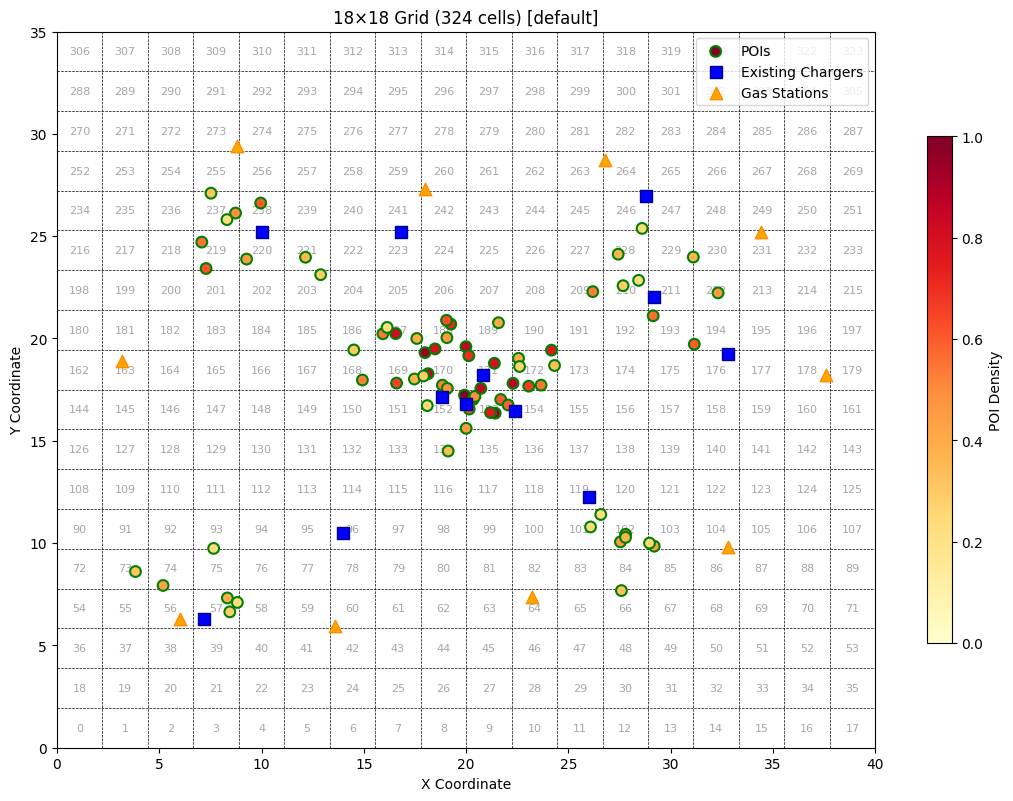

  Grid Info:
    Grid   56 (row=3, col=2): 1 gas station(s)
    Grid   57 (row=3, col=3): 3 POI(s) [densities: 0.38, 0.29, 0.23] | 1 charger(s)
    Grid   60 (row=3, col=6): 1 gas station(s)
    Grid   64 (row=3, col=10): 1 gas station(s)
    Grid   66 (row=3, col=12): 1 POI(s) [densities: 0.32]
    Grid   73 (row=4, col=1): 1 POI(s) [densities: 0.32]
    Grid   74 (row=4, col=2): 1 POI(s) [densities: 0.43]
    Grid   93 (row=5, col=3): 1 POI(s) [densities: 0.22]
    Grid   96 (row=5, col=6): 1 charger(s)
    Grid  101 (row=5, col=11): 2 POI(s) [densities: 0.24, 0.22]
    Grid  102 (row=5, col=12): 3 POI(s) [densities: 0.58, 0.46, 0.37]
    Grid  103 (row=5, col=13): 2 POI(s) [densities: 0.43, 0.25]
    Grid  104 (row=5, col=14): 1 gas station(s)
    Grid  119 (row=6, col=11): 1 charger(s)
    Grid  134 (row=7, col=8): 1 POI(s) [densities: 0.35]
    Grid  152 (row=8, col=8): 2 POI(s) [densities: 0.99, 0.24] | 1 charger(s)
    Grid  153 (row=8, col=9): 8 POI(s) [densities: 0.77, 0.63, 0

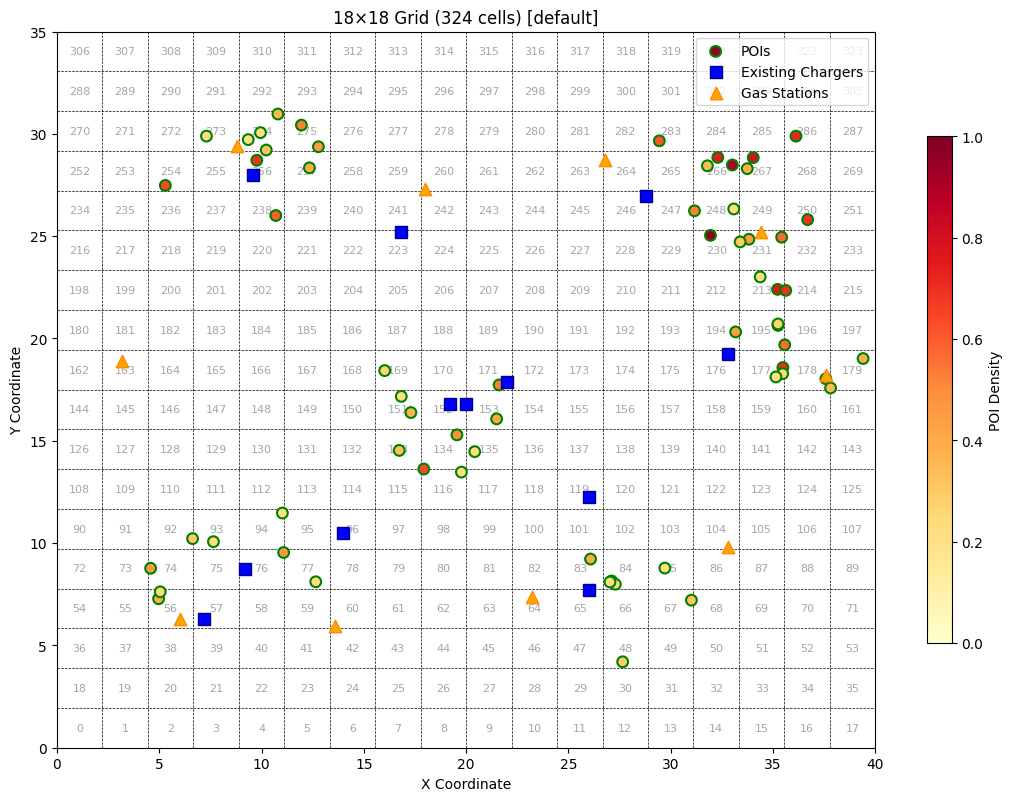

  Grid Info:
    Grid   48 (row=2, col=12): 1 POI(s) [densities: 0.29]
    Grid   56 (row=3, col=2): 2 POI(s) [densities: 0.38, 0.25] | 1 gas station(s)
    Grid   57 (row=3, col=3): 1 charger(s)
    Grid   60 (row=3, col=6): 1 gas station(s)
    Grid   64 (row=3, col=10): 1 gas station(s)
    Grid   65 (row=3, col=11): 1 charger(s)
    Grid   67 (row=3, col=13): 1 POI(s) [densities: 0.32]
    Grid   74 (row=4, col=2): 1 POI(s) [densities: 0.45]
    Grid   76 (row=4, col=4): 1 POI(s) [densities: 0.46] | 1 charger(s)
    Grid   77 (row=4, col=5): 1 POI(s) [densities: 0.22]
    Grid   83 (row=4, col=11): 1 POI(s) [densities: 0.40]
    Grid   84 (row=4, col=12): 3 POI(s) [densities: 0.40, 0.22, 0.22]
    Grid   85 (row=4, col=13): 1 POI(s) [densities: 0.22]
    Grid   92 (row=5, col=2): 1 POI(s) [densities: 0.30]
    Grid   93 (row=5, col=3): 1 POI(s) [densities: 0.22]
    Grid   94 (row=5, col=4): 1 POI(s) [densities: 0.22]
    Grid   96 (row=5, col=6): 1 charger(s)
    Grid  104 (row=5,

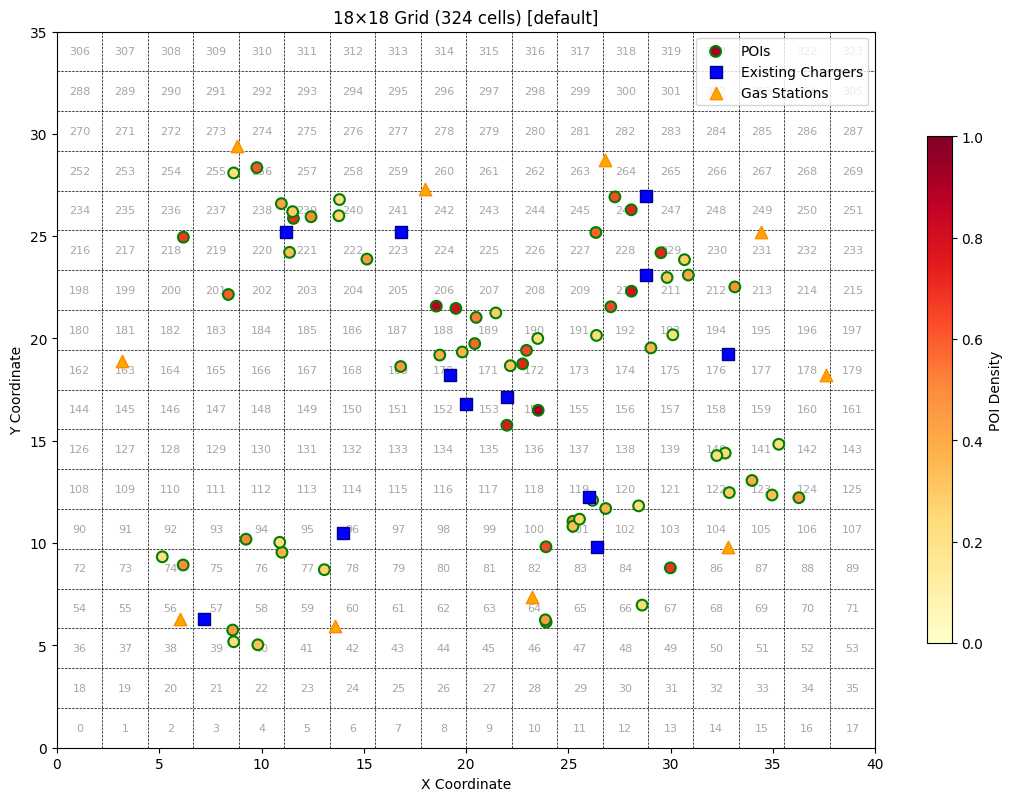

  Grid Info:
    Grid   39 (row=2, col=3): 2 POI(s) [densities: 0.45, 0.22]
    Grid   40 (row=2, col=4): 1 POI(s) [densities: 0.33]
    Grid   56 (row=3, col=2): 1 gas station(s)
    Grid   57 (row=3, col=3): 1 charger(s)
    Grid   60 (row=3, col=6): 1 gas station(s)
    Grid   64 (row=3, col=10): 2 POI(s) [densities: 0.52, 0.45] | 1 gas station(s)
    Grid   66 (row=3, col=12): 1 POI(s) [densities: 0.24]
    Grid   74 (row=4, col=2): 2 POI(s) [densities: 0.50, 0.22]
    Grid   76 (row=4, col=4): 1 POI(s) [densities: 0.38]
    Grid   77 (row=4, col=5): 1 POI(s) [densities: 0.27]
    Grid   85 (row=4, col=13): 1 POI(s) [densities: 0.69]
    Grid   94 (row=5, col=4): 2 POI(s) [densities: 0.51, 0.22]
    Grid   96 (row=5, col=6): 1 charger(s)
    Grid  100 (row=5, col=10): 1 POI(s) [densities: 0.64]
    Grid  101 (row=5, col=11): 3 POI(s) [densities: 0.48, 0.34, 0.26] | 1 charger(s)
    Grid  104 (row=5, col=14): 1 gas station(s)
    Grid  119 (row=6, col=11): 1 POI(s) [densities: 0.22]

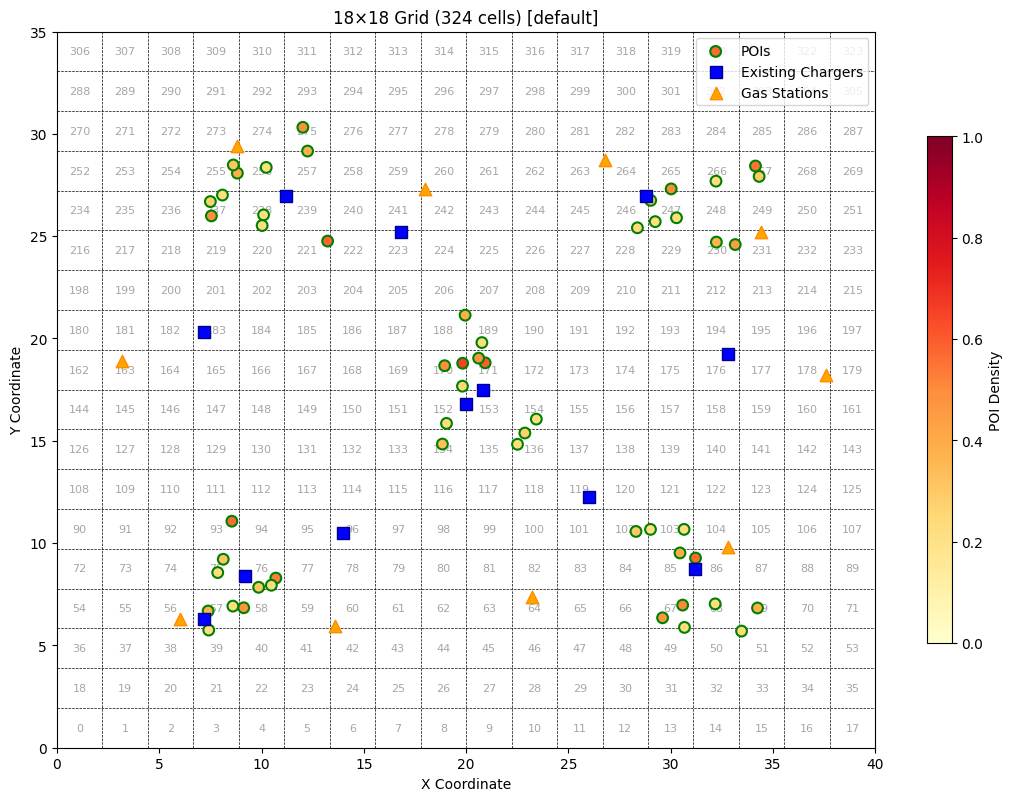

  Grid Info:
    Grid   39 (row=2, col=3): 1 POI(s) [densities: 0.22]
    Grid   51 (row=2, col=15): 1 POI(s) [densities: 0.24]
    Grid   56 (row=3, col=2): 1 gas station(s)
    Grid   57 (row=3, col=3): 2 POI(s) [densities: 0.37, 0.22] | 1 charger(s)
    Grid   58 (row=3, col=4): 1 POI(s) [densities: 0.48]
    Grid   60 (row=3, col=6): 1 gas station(s)
    Grid   64 (row=3, col=10): 1 gas station(s)
    Grid   67 (row=3, col=13): 3 POI(s) [densities: 0.51, 0.47, 0.22]
    Grid   68 (row=3, col=14): 1 POI(s) [densities: 0.22]
    Grid   69 (row=3, col=15): 1 POI(s) [densities: 0.39]
    Grid   75 (row=4, col=3): 2 POI(s) [densities: 0.31, 0.22]
    Grid   76 (row=4, col=4): 3 POI(s) [densities: 0.52, 0.31, 0.22] | 1 charger(s)
    Grid   85 (row=4, col=13): 1 POI(s) [densities: 0.40]
    Grid   86 (row=4, col=14): 1 POI(s) [densities: 0.57] | 1 charger(s)
    Grid   93 (row=5, col=3): 1 POI(s) [densities: 0.57]
    Grid   96 (row=5, col=6): 1 charger(s)
    Grid  102 (row=5, col=12): 

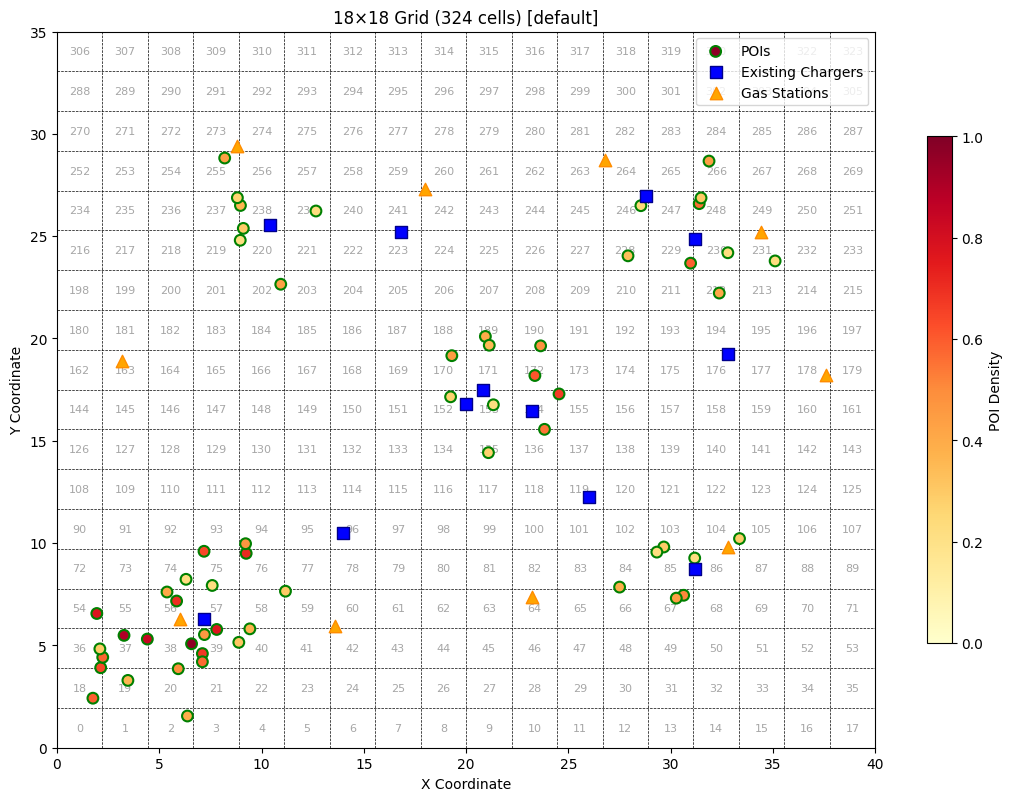

  Grid Info:
    Grid    2 (row=0, col=2): 1 POI(s) [densities: 0.39]
    Grid   18 (row=1, col=0): 1 POI(s) [densities: 0.59]
    Grid   19 (row=1, col=1): 1 POI(s) [densities: 0.36]
    Grid   20 (row=1, col=2): 1 POI(s) [densities: 0.49]
    Grid   36 (row=2, col=0): 2 POI(s) [densities: 0.64, 0.29]
    Grid   37 (row=2, col=1): 3 POI(s) [densities: 0.90, 0.84, 0.58]
    Grid   38 (row=2, col=2): 1 POI(s) [densities: 0.97]
    Grid   39 (row=2, col=3): 4 POI(s) [densities: 0.77, 0.68, 0.57, 0.46]
    Grid   40 (row=2, col=4): 2 POI(s) [densities: 0.37, 0.31]
    Grid   54 (row=3, col=0): 1 POI(s) [densities: 0.77]
    Grid   56 (row=3, col=2): 2 POI(s) [densities: 0.70, 0.41] | 1 gas station(s)
    Grid   57 (row=3, col=3): 1 charger(s)
    Grid   59 (row=3, col=5): 1 POI(s) [densities: 0.30]
    Grid   60 (row=3, col=6): 1 gas station(s)
    Grid   64 (row=3, col=10): 1 gas station(s)
    Grid   67 (row=3, col=13): 2 POI(s) [densities: 0.51, 0.44]
    Grid   74 (row=4, col=2): 1 PO

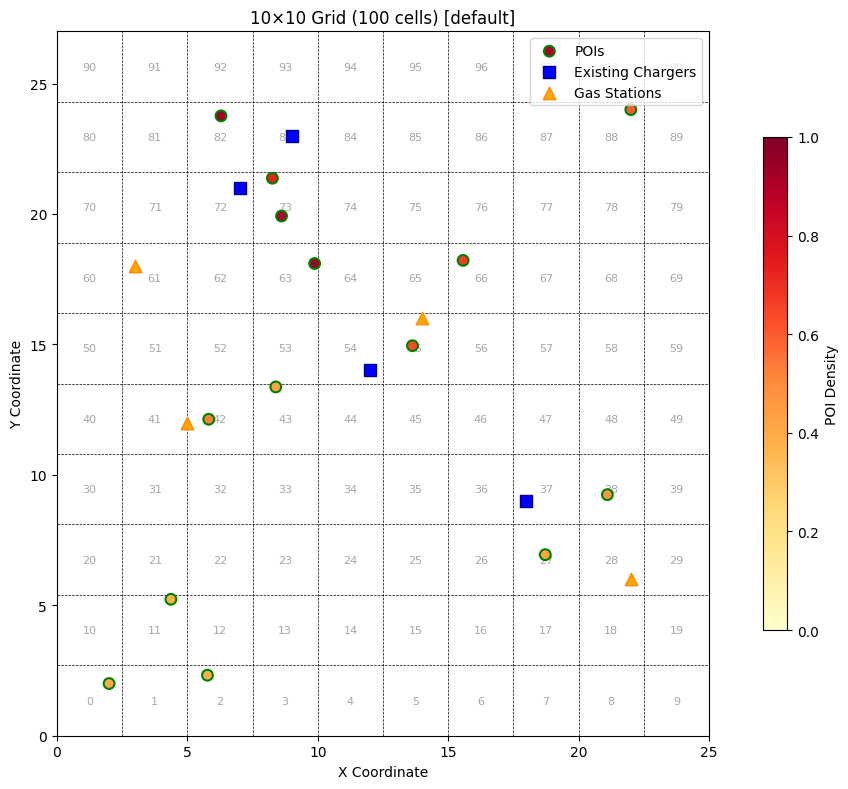

  Grid Info:
    Grid    0 (row=0, col=0): 1 POI(s) [densities: 0.40]
    Grid    2 (row=0, col=2): 1 POI(s) [densities: 0.38]
    Grid   11 (row=1, col=1): 1 POI(s) [densities: 0.38]
    Grid   27 (row=2, col=7): 1 POI(s) [densities: 0.42]
    Grid   28 (row=2, col=8): 1 gas station(s)
    Grid   29 (row=2, col=9): 1 POI(s) [densities: 0.38]
    Grid   37 (row=3, col=7): 1 charger(s)
    Grid   38 (row=3, col=8): 1 POI(s) [densities: 0.47]
    Grid   42 (row=4, col=2): 1 POI(s) [densities: 0.53] | 1 gas station(s)
    Grid   43 (row=4, col=3): 1 POI(s) [densities: 0.42]
    Grid   54 (row=5, col=4): 1 charger(s)
    Grid   55 (row=5, col=5): 1 POI(s) [densities: 0.63] | 1 gas station(s)
    Grid   61 (row=6, col=1): 1 gas station(s)
    Grid   63 (row=6, col=3): 1 POI(s) [densities: 0.94]
    Grid   66 (row=6, col=6): 1 POI(s) [densities: 0.67]
    Grid   72 (row=7, col=2): 1 charger(s)
    Grid   73 (row=7, col=3): 2 POI(s) [densities: 0.91, 0.73]
    Grid   82 (row=8, col=2): 1 POI(

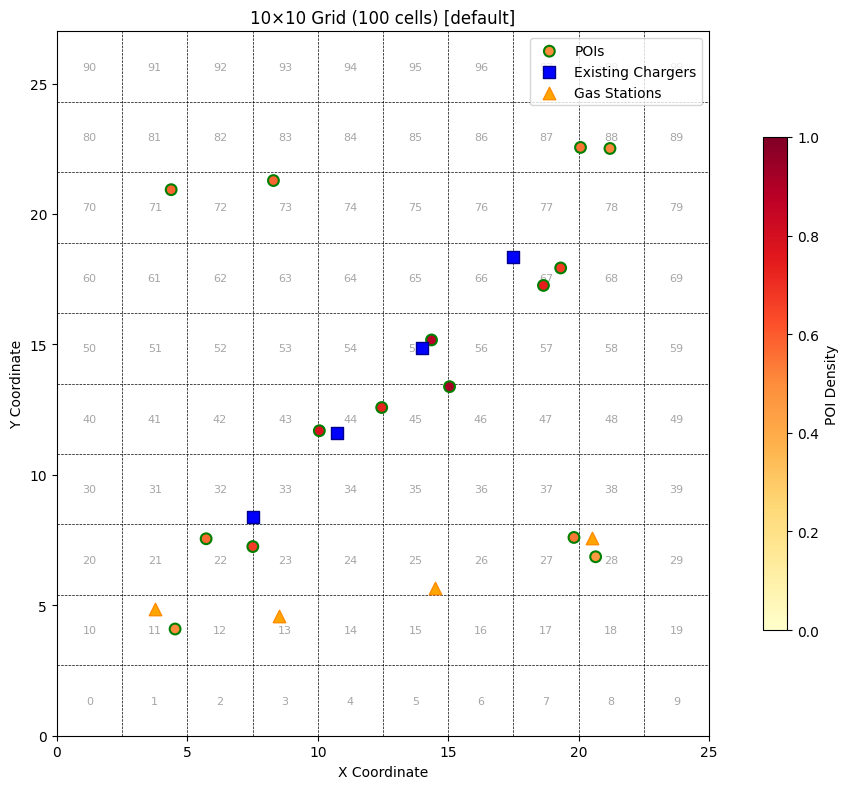

  Grid Info:
    Grid   11 (row=1, col=1): 1 POI(s) [densities: 0.50] | 1 gas station(s)
    Grid   13 (row=1, col=3): 1 gas station(s)
    Grid   22 (row=2, col=2): 1 POI(s) [densities: 0.57]
    Grid   23 (row=2, col=3): 1 POI(s) [densities: 0.67]
    Grid   25 (row=2, col=5): 1 gas station(s)
    Grid   27 (row=2, col=7): 1 POI(s) [densities: 0.54]
    Grid   28 (row=2, col=8): 1 POI(s) [densities: 0.46] | 1 gas station(s)
    Grid   33 (row=3, col=3): 1 charger(s)
    Grid   44 (row=4, col=4): 2 POI(s) [densities: 0.78, 0.73] | 1 charger(s)
    Grid   46 (row=4, col=6): 1 POI(s) [densities: 0.92]
    Grid   55 (row=5, col=5): 1 POI(s) [densities: 0.88] | 1 charger(s)
    Grid   67 (row=6, col=7): 2 POI(s) [densities: 0.74, 0.67] | 1 charger(s)
    Grid   71 (row=7, col=1): 1 POI(s) [densities: 0.58]
    Grid   73 (row=7, col=3): 1 POI(s) [densities: 0.58]
    Grid   88 (row=8, col=8): 2 POI(s) [densities: 0.55, 0.51]

small_city_corridor: N=100 m=4 seeds=[0, 1, 2, 3, 4]
  Running b

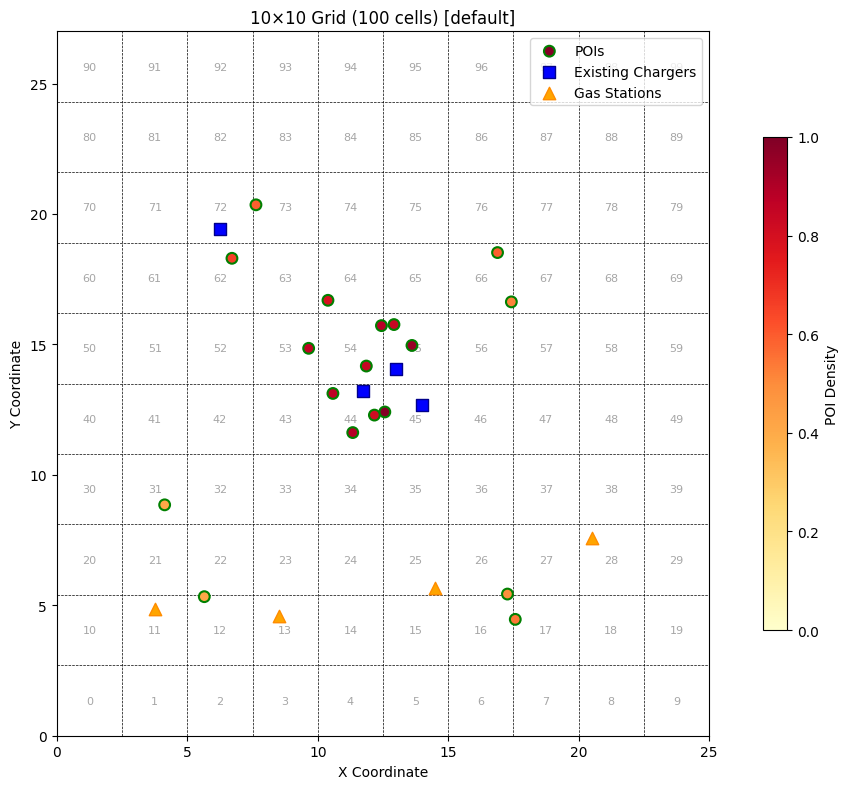

  Grid Info:
    Grid   11 (row=1, col=1): 1 gas station(s)
    Grid   12 (row=1, col=2): 1 POI(s) [densities: 0.41]
    Grid   13 (row=1, col=3): 1 gas station(s)
    Grid   17 (row=1, col=7): 1 POI(s) [densities: 0.54]
    Grid   25 (row=2, col=5): 1 gas station(s)
    Grid   26 (row=2, col=6): 1 POI(s) [densities: 0.49]
    Grid   28 (row=2, col=8): 1 gas station(s)
    Grid   31 (row=3, col=1): 1 POI(s) [densities: 0.41]
    Grid   44 (row=4, col=4): 3 POI(s) [densities: 0.89, 0.87, 0.82] | 1 charger(s)
    Grid   45 (row=4, col=5): 1 POI(s) [densities: 0.99] | 1 charger(s)
    Grid   53 (row=5, col=3): 1 POI(s) [densities: 0.86]
    Grid   54 (row=5, col=4): 2 POI(s) [densities: 0.88, 0.84]
    Grid   55 (row=5, col=5): 2 POI(s) [densities: 0.95, 0.84] | 1 charger(s)
    Grid   62 (row=6, col=2): 1 POI(s) [densities: 0.66]
    Grid   64 (row=6, col=4): 1 POI(s) [densities: 0.79]
    Grid   66 (row=6, col=6): 2 POI(s) [densities: 0.59, 0.52]
    Grid   72 (row=7, col=2): 1 charger(

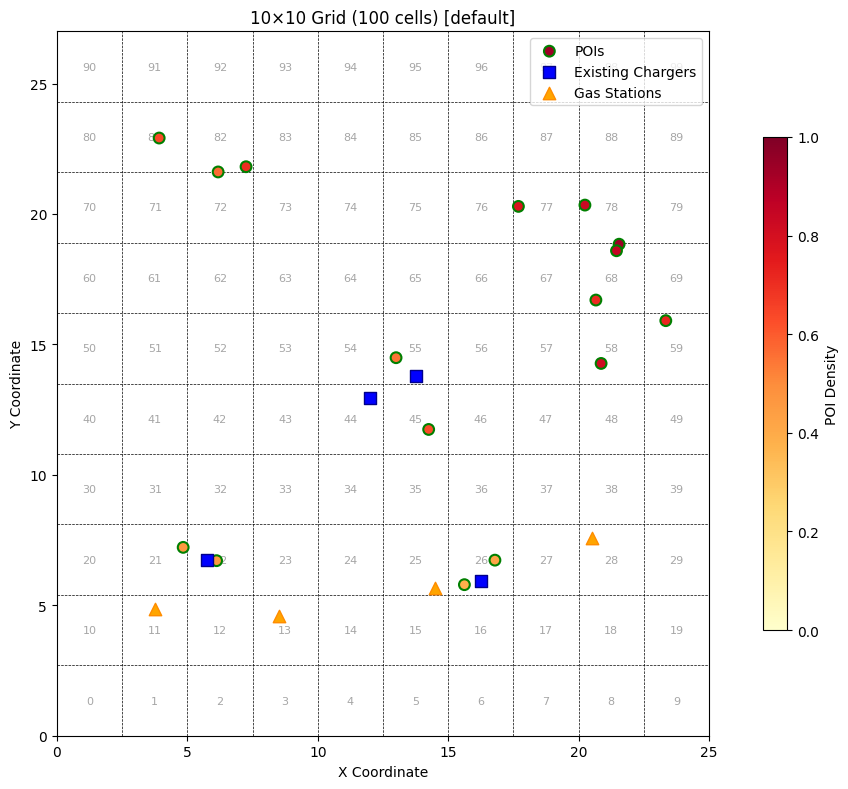

  Grid Info:
    Grid   11 (row=1, col=1): 1 gas station(s)
    Grid   13 (row=1, col=3): 1 gas station(s)
    Grid   21 (row=2, col=1): 1 POI(s) [densities: 0.46]
    Grid   22 (row=2, col=2): 1 POI(s) [densities: 0.46] | 1 charger(s)
    Grid   25 (row=2, col=5): 1 gas station(s)
    Grid   26 (row=2, col=6): 2 POI(s) [densities: 0.42, 0.38] | 1 charger(s)
    Grid   28 (row=2, col=8): 1 gas station(s)
    Grid   44 (row=4, col=4): 1 charger(s)
    Grid   45 (row=4, col=5): 1 POI(s) [densities: 0.63]
    Grid   55 (row=5, col=5): 1 POI(s) [densities: 0.55] | 1 charger(s)
    Grid   58 (row=5, col=8): 1 POI(s) [densities: 0.82]
    Grid   59 (row=5, col=9): 1 POI(s) [densities: 0.72]
    Grid   68 (row=6, col=8): 3 POI(s) [densities: 0.94, 0.85, 0.71]
    Grid   77 (row=7, col=7): 1 POI(s) [densities: 0.78]
    Grid   78 (row=7, col=8): 1 POI(s) [densities: 0.83]
    Grid   81 (row=8, col=1): 1 POI(s) [densities: 0.64]
    Grid   82 (row=8, col=2): 2 POI(s) [densities: 0.70, 0.57]

sm

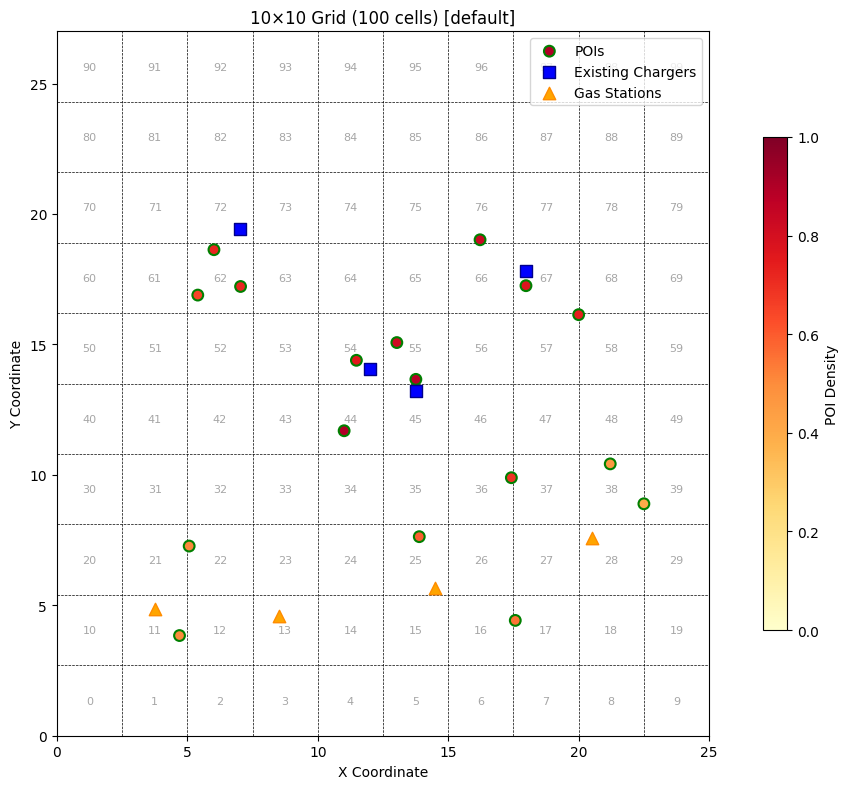

  Grid Info:
    Grid   11 (row=1, col=1): 1 POI(s) [densities: 0.50] | 1 gas station(s)
    Grid   13 (row=1, col=3): 1 gas station(s)
    Grid   17 (row=1, col=7): 1 POI(s) [densities: 0.55]
    Grid   22 (row=2, col=2): 1 POI(s) [densities: 0.51]
    Grid   25 (row=2, col=5): 1 POI(s) [densities: 0.59] | 1 gas station(s)
    Grid   28 (row=2, col=8): 1 gas station(s)
    Grid   36 (row=3, col=6): 1 POI(s) [densities: 0.69]
    Grid   38 (row=3, col=8): 1 POI(s) [densities: 0.46]
    Grid   39 (row=3, col=9): 1 POI(s) [densities: 0.40]
    Grid   44 (row=4, col=4): 1 POI(s) [densities: 0.90]
    Grid   45 (row=4, col=5): 1 charger(s)
    Grid   54 (row=5, col=4): 1 POI(s) [densities: 0.75] | 1 charger(s)
    Grid   55 (row=5, col=5): 2 POI(s) [densities: 0.89, 0.82]
    Grid   58 (row=5, col=8): 1 POI(s) [densities: 0.74]
    Grid   62 (row=6, col=2): 3 POI(s) [densities: 0.72, 0.72, 0.65]
    Grid   67 (row=6, col=7): 1 POI(s) [densities: 0.77] | 1 charger(s)
    Grid   72 (row=7, c

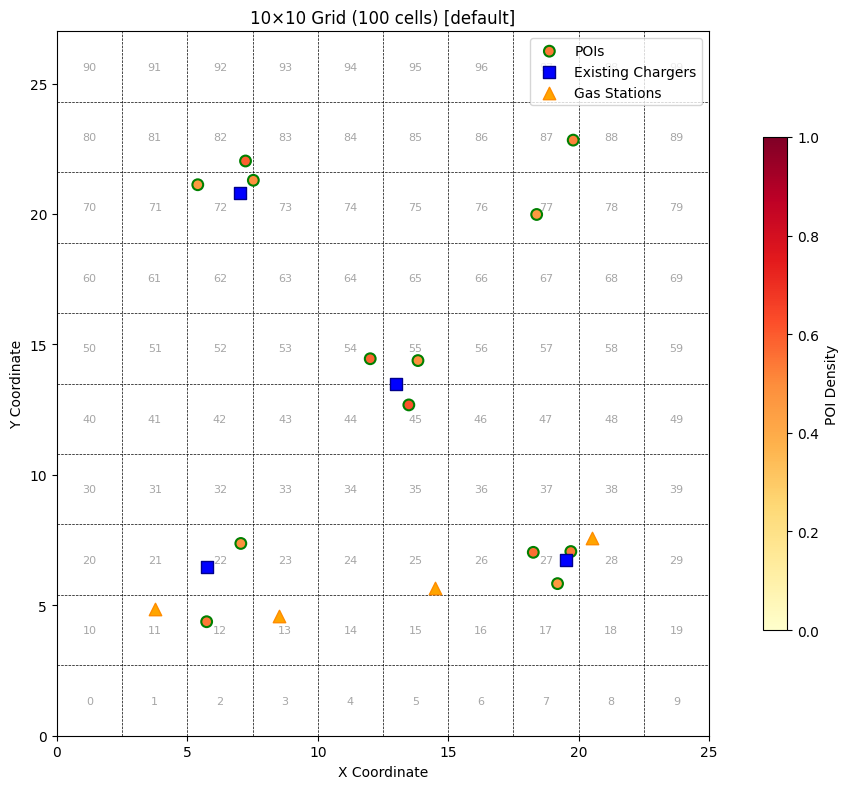

  Grid Info:
    Grid   11 (row=1, col=1): 1 gas station(s)
    Grid   12 (row=1, col=2): 1 POI(s) [densities: 0.54]
    Grid   13 (row=1, col=3): 1 gas station(s)
    Grid   22 (row=2, col=2): 1 POI(s) [densities: 0.49] | 1 charger(s)
    Grid   25 (row=2, col=5): 1 gas station(s)
    Grid   27 (row=2, col=7): 3 POI(s) [densities: 0.56, 0.54, 0.46] | 1 charger(s)
    Grid   28 (row=2, col=8): 1 gas station(s)
    Grid   45 (row=4, col=5): 1 POI(s) [densities: 0.62]
    Grid   54 (row=5, col=4): 1 POI(s) [densities: 0.58]
    Grid   55 (row=5, col=5): 1 POI(s) [densities: 0.49] | 1 charger(s)
    Grid   72 (row=7, col=2): 1 POI(s) [densities: 0.46] | 1 charger(s)
    Grid   73 (row=7, col=3): 1 POI(s) [densities: 0.49]
    Grid   77 (row=7, col=7): 1 POI(s) [densities: 0.46]
    Grid   82 (row=8, col=2): 1 POI(s) [densities: 0.59]
    Grid   87 (row=8, col=7): 1 POI(s) [densities: 0.52]

small_city_sparse_suburban: N=100 m=4 seeds=[0, 1, 2, 3, 4]
  Running baseline...
  Running tuned_q

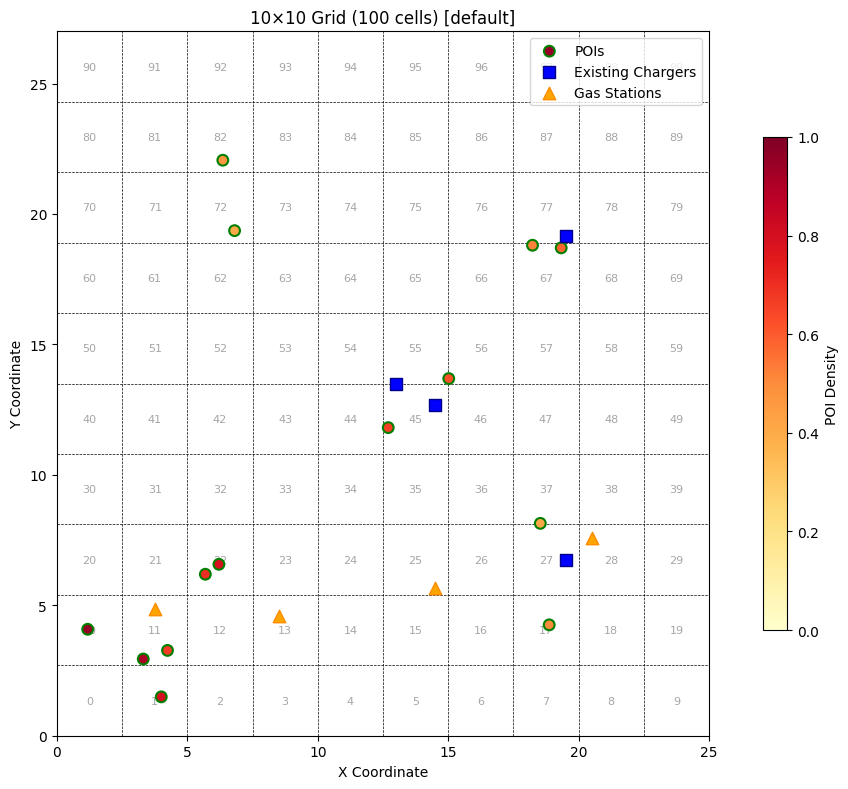

  Grid Info:
    Grid    1 (row=0, col=1): 1 POI(s) [densities: 0.80]
    Grid   10 (row=1, col=0): 1 POI(s) [densities: 0.95]
    Grid   11 (row=1, col=1): 2 POI(s) [densities: 0.91, 0.67] | 1 gas station(s)
    Grid   13 (row=1, col=3): 1 gas station(s)
    Grid   17 (row=1, col=7): 1 POI(s) [densities: 0.50]
    Grid   22 (row=2, col=2): 2 POI(s) [densities: 0.79, 0.70]
    Grid   25 (row=2, col=5): 1 gas station(s)
    Grid   27 (row=2, col=7): 1 charger(s)
    Grid   28 (row=2, col=8): 1 gas station(s)
    Grid   37 (row=3, col=7): 1 POI(s) [densities: 0.41]
    Grid   45 (row=4, col=5): 1 POI(s) [densities: 0.66] | 1 charger(s)
    Grid   55 (row=5, col=5): 1 charger(s)
    Grid   56 (row=5, col=6): 1 POI(s) [densities: 0.62]
    Grid   67 (row=6, col=7): 2 POI(s) [densities: 0.58, 0.52]
    Grid   72 (row=7, col=2): 1 POI(s) [densities: 0.41]
    Grid   77 (row=7, col=7): 1 charger(s)
    Grid   82 (row=8, col=2): 1 POI(s) [densities: 0.47]

small_city_underserved_corner: N=100 

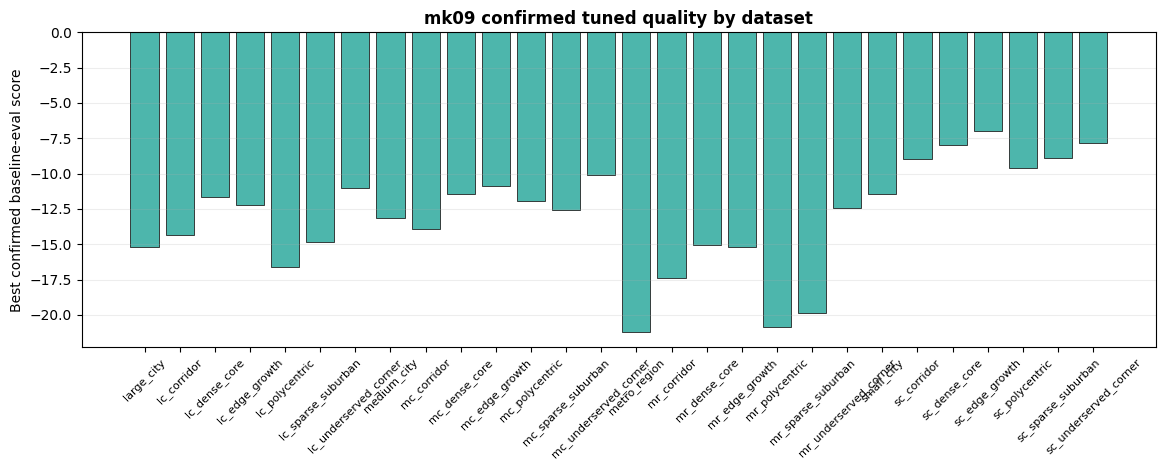

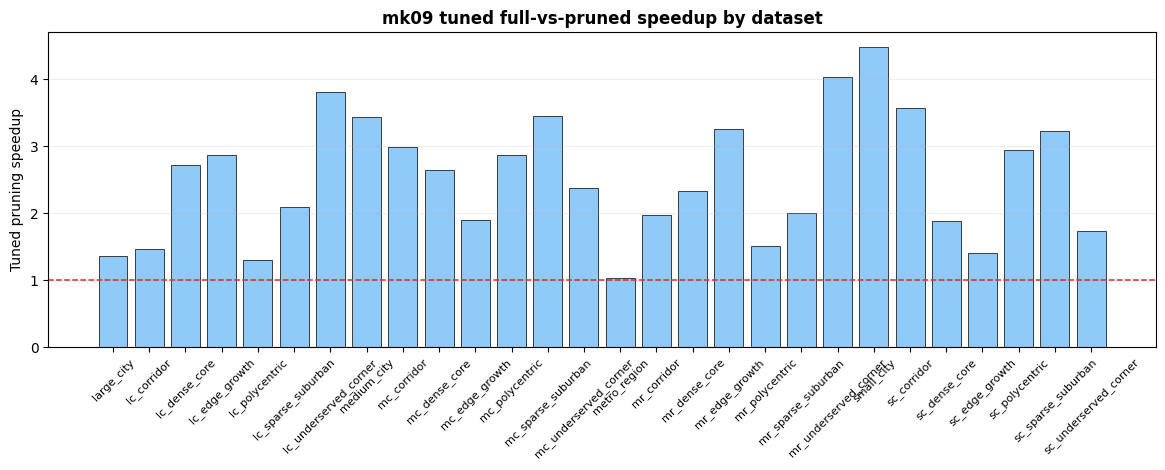


All mk09 results -> /Users/abhimuvva/Documents/Proj_HGQA/results/classical_tuning/mk09_confirmed_tuning_20260528_133954


In [7]:
# -----------------------------------------------------------------------------
# 6. Run all selected datasets and save cross-dataset summary
# -----------------------------------------------------------------------------
all_confirmations = {}
_t0 = time.perf_counter()

for ds_name in DATASET_NAMES:
    all_confirmations[ds_name] = confirm_dataset(ds_name)

rows = []
for ds, payload in all_confirmations.items():
    best = payload['best_confirmed']
    eff = payload['tuned_full_vs_pruned']
    rows.append([
        ds, payload['N'], payload['m'],
        best['label'], f'{best["baseline_eval"]:.4f}', str(best['best_cells']),
        f'{eff["full_mean_time"]:.3f}s', f'{eff["pruned_mean_time"]:.3f}s', f'{eff["speedup"]:.2f}x'
    ])

print('\nMK09 CROSS-DATASET CONFIRMATION SUMMARY')
print(tabulate(rows, headers=['dataset', 'N', 'm', 'best_config', 'baseline_eval', 'best_cells', 'full_time', 'pruned_time', 'speedup'], tablefmt='simple'))

(MK09_RUN_DIR / 'mk09_cross_dataset_summary.json').write_text(json.dumps({
    'timestamp': datetime.now().isoformat(timespec='seconds'),
    'source_run': str(SOURCE_RUN_PATH),
    'runtime_sec': time.perf_counter() - _t0,
    'datasets': list(all_confirmations.keys()),
    'summaries': all_confirmations,
}, indent=2, default=str))

# Separate cross-dataset publication plots.
labels = list(all_confirmations.keys())
best_scores = [all_confirmations[d]['best_confirmed']['baseline_eval'] for d in labels]
speedups = [all_confirmations[d]['tuned_full_vs_pruned']['speedup'] for d in labels]
short = [x.replace('medium_city_', 'mc_').replace('small_city_', 'sc_').replace('large_city_', 'lc_').replace('metro_region_', 'mr_') for x in labels]

fig, ax = plt.subplots(figsize=(max(10, 0.42*len(labels)), 4.8))
ax.bar(short, best_scores, color='#4DB6AC', edgecolor='#222222', linewidth=0.6)
ax.set_ylabel('Best confirmed baseline-eval score')
ax.set_title('mk09 confirmed tuned quality by dataset', fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.grid(True, axis='y', alpha=0.22)
fig.tight_layout(); fig.savefig(MK09_RUN_DIR / 'cross_dataset_confirmed_quality.png', dpi=300, bbox_inches='tight'); plt.show()

fig, ax = plt.subplots(figsize=(max(10, 0.42*len(labels)), 4.8))
ax.bar(short, speedups, color='#90CAF9', edgecolor='#222222', linewidth=0.6)
ax.axhline(1.0, color='#D32F2F', linestyle='--', linewidth=1.1)
ax.set_ylabel('Tuned pruning speedup')
ax.set_title('mk09 tuned full-vs-pruned speedup by dataset', fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.grid(True, axis='y', alpha=0.22)
fig.tight_layout(); fig.savefig(MK09_RUN_DIR / 'cross_dataset_tuned_speedup.png', dpi=300, bbox_inches='tight'); plt.show()

print(f'\nAll mk09 results -> {MK09_RUN_DIR}')